In [1]:
%load_ext autoreload
%autoreload 2

import json

import logging

logging.basicConfig(level=logging.INFO, format="[%(asctime)s] %(name)s[%(levelname)s]: %(message)s", datefmt="%H:%M:%S")

from eval_scripts.results_processing.base import RunsInfo, load_runs  # noqa: E402
from eval_scripts.results_processing.tag_runs import filter_and_tag_runs # noqa: E402


SCANNETPP_SCENE_SELECTION = "c5439f4607,bcd2436daf,b0a08200c9,6115eddb86,f3d64c30f8,3f15a9266d,5eb31827b7,3db0a1c8f3,40aec5fffa,9071e139d9,e7af285f7d,bde1e479ad,5748ce6f01,825d228aec,7831862f02"
SCANNETPP_SCENE_SELECTION = SCANNETPP_SCENE_SELECTION.split(",")
TANKSANDTEMPLES_SCENE_SELECTION = "auditorium,ballroom,palace,temple,family,horse,lighthouse,m60,train,barn,caterpillar,church,meetingroom,truck"
TANKSANDTEMPLES_SCENE_SELECTION = TANKSANDTEMPLES_SCENE_SELECTION.split(",")
MIPNERF360_SCENE_SELECTION = (
    "garden,bicycle,flowers,treehill,stump,kitchen,bonsai,counter,room"
)
MIPNERF360_SCENE_SELECTION = MIPNERF360_SCENE_SELECTION.split(",")
DATASET_SCENE_SELECTION = {
    "eth3d": {
        "eth3d/pipes",
        "eth3d/kicker",
        "eth3d/terrace",
        "eth3d/relief",
        "eth3d/relief_2",
        "eth3d/terrains",
        "eth3d/office",
    },
    "scannet++": set(f"scannet++/{scene}" for scene in SCANNETPP_SCENE_SELECTION),
    "eval_on_train_set_scannet++": set(
        f"eval_on_train_set_scannet++/{scene}" for scene in SCANNETPP_SCENE_SELECTION
    ),
    "mipnerf360": set(f"mipnerf360/{scene}" for scene in MIPNERF360_SCENE_SELECTION),
    "tanksandtemples": set(
        f"tanksandtemples/{scene}" for scene in TANKSANDTEMPLES_SCENE_SELECTION
    ),
}

MCMC_OPACITY_REG_PER_DATASET: dict[str, str] = {
    "scannet++": "0.0005",
    "eval_on_train_set_scannet++": "0.0005",
    "eth3d": "0.01",
    "mipnerf360": "0.01",
    "tanksandtemples": "0.01",
}

DEFAULT_MEANS_LR_INIT = 0.00016

STRATEGY_NAMES = {
    "DefaultWithGaussianCapStrategy": "AbsGS",
    "DefaultWithoutADCStrategy": "No D.",
    "MCMCStrategy": "MCMC",
    "IDHFRStrategy": "IDHFR",
}
COMMON_DEFAULT_ARGS = {
    "nanogs_simplify_iter": "-1",
    "means_lr_init": str(DEFAULT_MEANS_LR_INIT),
}
DEFAULT_STRATEGY_ARGS = {
    "DefaultWithGaussianCapStrategy": {
        "strategy": "DefaultWithGaussianCapStrategy",
        "strategy.grow_grad2d": "0.0004",
        **COMMON_DEFAULT_ARGS
    },
    "DefaultWithoutADCStrategy": {
        "strategy": "DefaultWithoutADCStrategy",
        **COMMON_DEFAULT_ARGS
    },
    "MCMCStrategy": {
        "strategy": "MCMCStrategy",
        "opacity_reg": MCMC_OPACITY_REG_PER_DATASET,
        **COMMON_DEFAULT_ARGS
    },
    "IDHFRStrategy": {
        "strategy": "IDHFRStrategy",
        **COMMON_DEFAULT_ARGS
    },
}

def get_default_strategy_args(strategy: str, dataset: str) -> dict[str, str | float]:
    args = DEFAULT_STRATEGY_ARGS[strategy]
    return {
        key: (value[dataset] if isinstance(value, dict) else value)
        for key, value in args.items()
    }

runs_per_dataset: dict[str, RunsInfo] = {}

num_pts_per_scene = json.load(open("gmax_per_scene.json", "r"))
sfm_init_num_pts_per_scene = json.load(open("init_sfm_pts_per_scene.json", "r"))
real_init_num_pts_per_scene = json.load(
    open("real_init_num_points_per_scene.json", "r")
)

TRACKING_URI = "http://localhost:6069"

GT_DATASETS = [
    "scannet++",
    "eval_on_train_set_scannet++",
    "eth3d",
]
GT_DATASETS_WITHOUT_ETH3D = list(set(GT_DATASETS) - {"eth3d"})
OTHER_DATASETS = ["mipnerf360", "tanksandtemples"]
ALL_DATASETS = GT_DATASETS + OTHER_DATASETS
ALL_DATASETS_WITHOUT_ETH3D = list(set(ALL_DATASETS) - {"eth3d"})

for dataset in ALL_DATASETS:
    runs = load_runs(
        query=f"params.scene like '{dataset}%'",
        tracking_uri=TRACKING_URI,
    )
    if dataset in DATASET_SCENE_SELECTION:
        scenes = DATASET_SCENE_SELECTION[dataset]
        runs.df = runs.df[
            runs.df["scene"].isin(scenes)
        ]

    # Older runs used gt_pointcloud but it was since renamed to laser_scan as it better reflects the actual initialization method.
    runs.df["init_method"] = runs.df["init_method"].replace("gt_pointcloud", "laser_scan")
    # The Knn implementation was changed to accept the number of neighbors besides self instead of including self.
    runs.df["dense_init.knn_num_neighbors"] = runs.df["dense_init.knn_num_neighbors"].replace("4", "3")

    # The default was changed to true. For all non-splat inits, this value is not relevant.
    # Set it to true to avoid differing params/false non-duplicates. 
    # (Unfortunately no way to update existing parameter through mlflow API.)
    runs.df.loc[
        runs.df["init_type"] != "splat", "splat_init.increase_scale_with_fewer_splats"
    ] = True

    runs = filter_and_tag_runs(runs, tracking_uri=TRACKING_URI, 
                    gmax_per_scene=num_pts_per_scene, 
                    sfm_init_num_pts_per_scene=sfm_init_num_pts_per_scene, 
                    real_init_num_pts_per_scene=real_init_num_pts_per_scene, 
                    get_default_strategy_args=get_default_strategy_args)

    # Remove identical runs - these are not necessarily created erroneously, as the same parameter combination
    # can be correctly ran twice e.g. when running laser scan init with cap_max which happens to be the same as gmax.
    # But the later code can't handle duplicates unless there is the same number of instances for each scene.
    params_per_run = runs.df[list(runs.param_names)]
    identical_runs = params_per_run.duplicated(keep="last")
    if identical_runs.any():
        print(
            "Num duplicates: ",
            identical_runs.sum(),
        )
    # drop rows with identical params, keeping only the first occurrence:
    runs.df = runs.df[~identical_runs]
    print("Num runs after dropping duplicates: ", len(runs.df))
    runs_per_dataset[dataset] = runs

[10:19:55] numexpr.utils[INFO]: NumExpr defaulting to 12 threads.
[10:19:55] eval_scripts.common.dataset_scenes[WARNING]: SCANNETPP_PATH environment variable not set. dataset_scenes.SCENES_PER_DATASET will not contain scannet++ scenes.
[10:19:55] eval_scripts.common.dataset_scenes[WARNING]: SCANNETPP_PATH environment variable not set. dataset_scenes.SCENES_PER_DATASET will not contain scannet++ scenes.
[10:19:55] eval_scripts.common.dataset_scenes[WARNING]: ETH3D_PATH environment variable not set. dataset_scenes.SCENES_PER_DATASET will not contain eth3d scenes.


{'mipnerf360': ['mipnerf360/garden', 'mipnerf360/bicycle', 'mipnerf360/flowers', 'mipnerf360/treehill', 'mipnerf360/stump', 'mipnerf360/kitchen', 'mipnerf360/bonsai', 'mipnerf360/counter', 'mipnerf360/room'], 'tanksandtemples': ['tanksandtemples/auditorium', 'tanksandtemples/ballroom', 'tanksandtemples/courtroom', 'tanksandtemples/museum', 'tanksandtemples/palace', 'tanksandtemples/temple', 'tanksandtemples/family', 'tanksandtemples/francis', 'tanksandtemples/horse', 'tanksandtemples/lighthouse', 'tanksandtemples/m60', 'tanksandtemples/panther', 'tanksandtemples/playground', 'tanksandtemples/train', 'tanksandtemples/barn', 'tanksandtemples/caterpillar', 'tanksandtemples/church', 'tanksandtemples/courthouse', 'tanksandtemples/ignatius', 'tanksandtemples/meetingroom', 'tanksandtemples/truck'], 'scannet++': [], 'eval_on_train_set_scannet++': [], 'eth3d': []}
Filtering out 435 anomalous runs.
Num duplicates:  52
Num runs after dropping duplicates:  904
Filtering out 408 anomalous runs.
Num

In [2]:
# helpers
from pathlib import Path
import re    

def fraction_name(fraction: str | float) -> str:
    return f"{float(fraction) * 100:.0f}% $G_\\mathit{{max}}$"


PLOT_RANGES_PER_METRIC_SCANNETPP: dict[str, tuple[float, float]] = {
    "eval-all-test/psnr": (15, 35.5),
    "eval-all-test/ssim": (0.7, 1.0),
    "eval-all-test/lpips": (0.0, 0.4),
    "train/num-gaussians": (0, 5e6),
    "train/total-train-time": (0, 90),
    "PSNR per 1M Gaussians ↑": (5, 18),
    "SSIM per 1M Gaussians ↑": (0.25, 0.5),
    "(1 - LPIPS) per 1M Gaussians ↑": (0.15, 0.4),
}

PLOT_RANGES_PER_METRIC_ETH3D: dict[str, tuple[float, float]] = {
    "eval-all-test/psnr": (15, 35),
    "eval-all-test/ssim": (0.7, 1.0),
    "eval-all-test/lpips": (0.0, 0.4),
    "train/num-gaussians": (0, 8e6),
    "train/total-train-time": (0, 90),
    "PSNR per 1M Gaussians ↑": (1, 14),
    "SSIM per 1M Gaussians ↑": (0.1, 0.35),
    "(1 - LPIPS) per 1M Gaussians ↑": (0.05, 0.3),
}

PLOT_RANGES_PER_METRIC: dict[str, dict[str, tuple[float, float]]] = {
    "scannet++": PLOT_RANGES_PER_METRIC_SCANNETPP,
    "eval_on_train_set_scannet++": PLOT_RANGES_PER_METRIC_SCANNETPP,
    "eth3d": PLOT_RANGES_PER_METRIC_ETH3D,
}

PLOT_RANGES_PER_METRIC_FRACTIONS: dict[str, tuple[float, float]] = {
    key: (0.8, 1.5) if not key.lower().endswith("lpips") else (0.5, 1.2)
    for key in PLOT_RANGES_PER_METRIC_SCANNETPP.keys()
}


def _name_to_path(value: str, allow_subdirs: bool) -> str:
    value = value.replace("scannet++", "scannetpp")
    for strategy in STRATEGY_NAMES.keys():
        value = value.replace(
            strategy, STRATEGY_NAMES[strategy].lower().replace(" ", "_")
        )
    if allow_subdirs:
        slug = re.sub(r"[^/a-zA-Z0-9._-]+", "_", value.strip())
    else:
        slug = re.sub(r"[^a-zA-Z0-9._-]+", "_", value.strip())
    return slug.strip("_") or "figure"


def save_figure_svg(fig, cell_subdir: str, figure_name: str, **kwargs) -> Path:
    output_dir = Path("graphs") / _name_to_path(cell_subdir, allow_subdirs=True)
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{_name_to_path(figure_name, allow_subdirs=False)}.svg"
    default_args = {
        "bbox_inches": "tight",
    }
    for key, value in default_args.items():
        kwargs.setdefault(key, value)
    fig.savefig(output_path, format="svg", **kwargs)
    print(f"Saved: {output_path}")
    return output_path

Dataset: scannet++
Common scenes (15): scannet++/6115eddb86, scannet++/9071e139d9, scannet++/3db0a1c8f3, scannet++/f3d64c30f8, scannet++/e7af285f7d, scannet++/c5439f4607, scannet++/825d228aec, scannet++/bcd2436daf, scannet++/b0a08200c9, scannet++/5eb31827b7, scannet++/3f15a9266d, scannet++/40aec5fffa, scannet++/5748ce6f01, scannet++/bde1e479ad, scannet++/7831862f02
Saved: graphs/gt_init_diff_strategies_and_sizes/scannetpp_line_metrics.svg


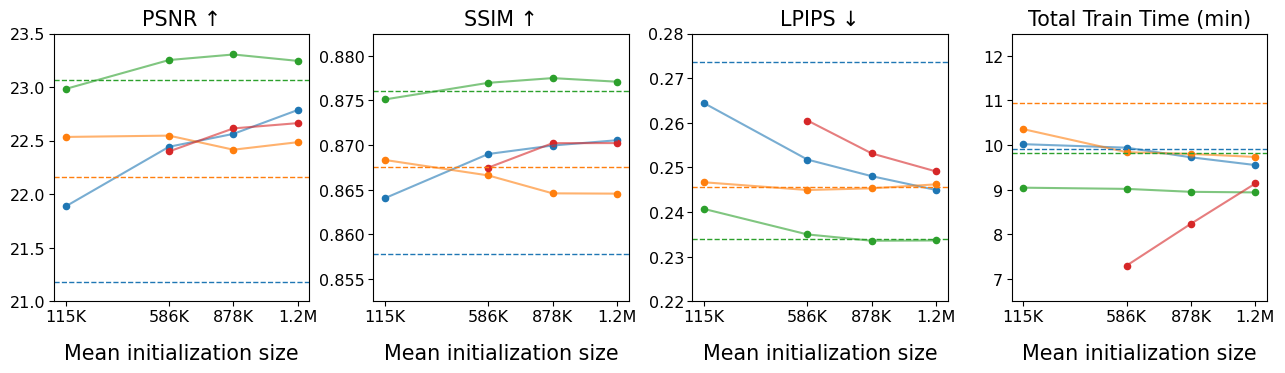

Saved: graphs/gt_init_diff_strategies_and_sizes/main_graph_legend.svg


<Figure size 1565.22x52.1739 with 0 Axes>

Dataset: eval_on_train_set_scannet++
Common scenes (15): eval_on_train_set_scannet++/f3d64c30f8, eval_on_train_set_scannet++/3db0a1c8f3, eval_on_train_set_scannet++/bde1e479ad, eval_on_train_set_scannet++/7831862f02, eval_on_train_set_scannet++/5eb31827b7, eval_on_train_set_scannet++/40aec5fffa, eval_on_train_set_scannet++/bcd2436daf, eval_on_train_set_scannet++/b0a08200c9, eval_on_train_set_scannet++/825d228aec, eval_on_train_set_scannet++/6115eddb86, eval_on_train_set_scannet++/c5439f4607, eval_on_train_set_scannet++/9071e139d9, eval_on_train_set_scannet++/5748ce6f01, eval_on_train_set_scannet++/e7af285f7d, eval_on_train_set_scannet++/3f15a9266d
Saved: graphs/gt_init_diff_strategies_and_sizes/eval_on_train_set_scannetpp_line_metrics.svg


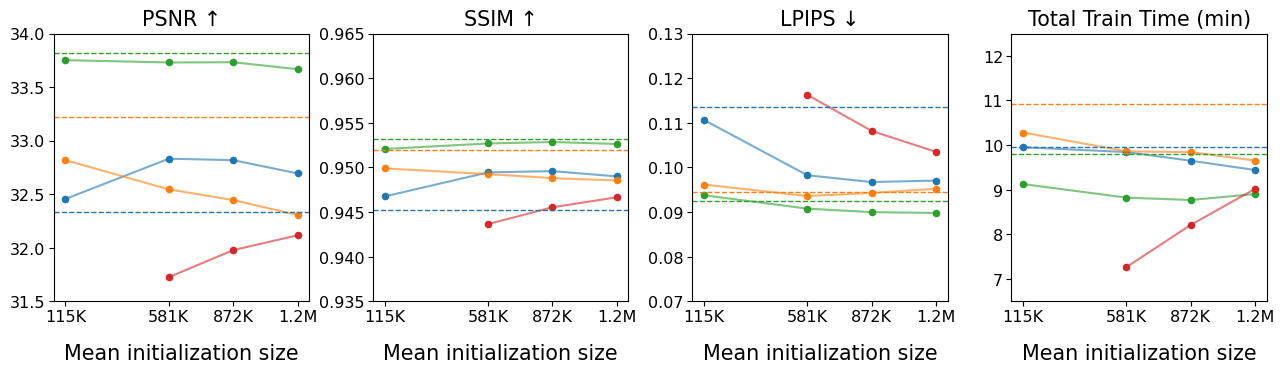

Saved: graphs/gt_init_diff_strategies_and_sizes/main_graph_legend.svg


<Figure size 1565.22x52.1739 with 0 Axes>

Dataset: eth3d
Common scenes (7): eth3d/terrains, eth3d/terrace, eth3d/office, eth3d/relief_2, eth3d/kicker, eth3d/pipes, eth3d/relief
Saved: graphs/gt_init_diff_strategies_and_sizes/eth3d_line_metrics.svg


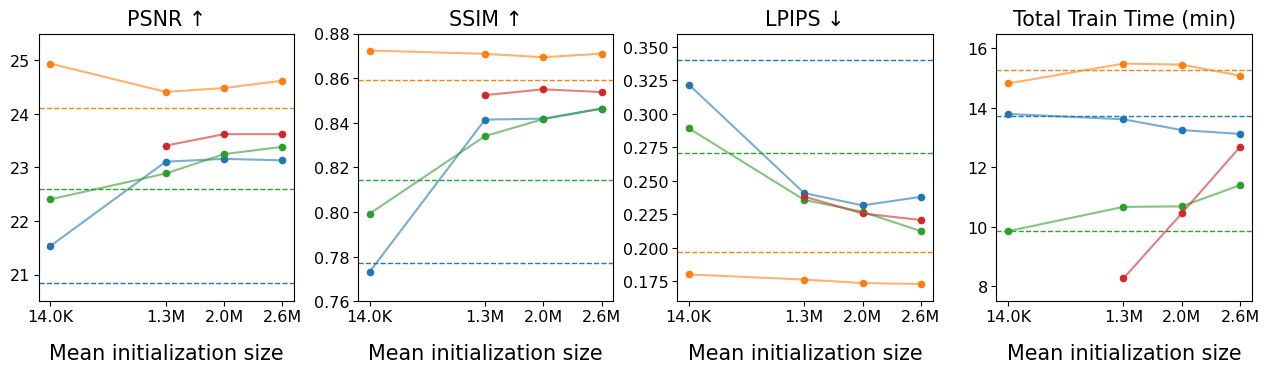

Saved: graphs/gt_init_diff_strategies_and_sizes/main_graph_legend.svg


<Figure size 1565.22x52.1739 with 0 Axes>

In [3]:
# Main graph - different strategies at different init sizes
from matplotlib import pyplot as plt
from eval_scripts.results_processing.base import (
    TABLE_METRICS,
    drop_scenes_not_present_in_all,
)
from eval_scripts.results_processing.plots import (
    grouped_per_metric_line_charts_for_each_config,
)


common_args = {
    "is_default_strategy_config": True,
    "init.position_noise_std": "0.0",
    "gaussian_cap_fraction": "1.0",
}
CELL_GRAPH_SUBDIR = "gt_init_diff_strategies_and_sizes"

for dataset in GT_DATASETS:
    print("Dataset:", dataset)
    runs = runs_per_dataset[dataset]

    data = {}

    sfm = runs.get_per_scene_metrics_for_params(
        {
            "init_group": "sfm_baseline",
            "strategy": "DefaultWithGaussianCapStrategy",
        }
    )

    sfm_mcmc = runs.get_per_scene_metrics_for_params(
        {
            "init_group": "sfm_baseline",
            "strategy": "MCMCStrategy",
        }
    )

    sfm_idhfr = runs.get_per_scene_metrics_for_params(
        {
            "init_group": "sfm_baseline",
            "strategy": "IDHFRStrategy",
        }
    )

    for strategy in ["DefaultWithGaussianCapStrategy", "MCMCStrategy", "IDHFRStrategy"]:
        args = {
            **common_args,
            "strategy": strategy,
            "init_method": "laser_scan",
            "init_size_matches_sfm": True,
        }
        x = runs.get_per_scene_metrics_for_params(
            args,
            metrics=TABLE_METRICS
            + ["dense_init.target_num_points", "dense_init.target_points_fraction"],
        )
        strat_name = STRATEGY_NAMES[strategy]
        data.setdefault(strat_name, {})["as_sfm"] = x

    for strategy in [
        "DefaultWithGaussianCapStrategy",
        "MCMCStrategy",
        "DefaultWithoutADCStrategy",
        "IDHFRStrategy",
    ]:
        for size_fraction in ["0.5", "0.75", "1.0"]:
            args = {
                **common_args,
                "strategy": strategy,
                "dense_init.target_points_fraction": size_fraction,
                "init_method": "laser_scan",
                "init_size_matches_gmax": True,
            }
            runs = runs.copy()
            x = runs.get_per_scene_metrics_for_params(
                args,
                metrics=TABLE_METRICS
                + ["dense_init.target_num_points", "dense_init.target_points_fraction"],
            )
            strat_name = STRATEGY_NAMES[strategy]
            data.setdefault(strat_name, {})[size_fraction] = x

    all_dfs = [sfm, sfm_mcmc] + [x for g in data.values() for x in g.values()]
    drop_scenes_not_present_in_all(*all_dfs)

    data_with_num_points = {}
    for strategy, df_per_fraction in data.items():
        data_with_num_points[strategy] = {}
        for fraction, df in df_per_fraction.items():
            df["dense_init.target_num_points"] = df[
                "dense_init.target_num_points"
            ].astype(float)
            # All should have same fraction
            assert (
                df["dense_init.target_points_fraction"]
                == df["dense_init.target_points_fraction"].iloc[0]
            ).all()
            df["dense_init.target_points_fraction"] = df[
                "dense_init.target_points_fraction"
            ].astype(float)
            num_points = (
                df["dense_init.target_num_points"]
                * df["dense_init.target_points_fraction"].iloc[0]
            )
            data_with_num_points[strategy][num_points.mean()] = df
    data_with_num_points = {
        a: {b: df.mean() for b, df in dfs.items()}
        for a, dfs in data_with_num_points.items()
    }

    plot_ranges_per_metric_per_dataset = {
        "default": {
            "eval-all-test/psnr": 2.5,
            "eval-all-test/ssim": 0.03,
            "eval-all-test/lpips": 0.06,
            "train/total-train-time": 6,
        },
        "eth3d": {
            "eval-all-test/psnr": 5,
            "eval-all-test/ssim": 0.12,
            "eval-all-test/lpips": 0.2,
            "train/total-train-time": 9,
        },
    }
    plot_starts_per_metric_per_dataset = {
        "scannet++": {
            "eval-all-test/psnr": 21,
            "eval-all-test/ssim": 0.8525,
            "eval-all-test/lpips": 0.22,
            "train/total-train-time": 6.5,
        },
        "eval_on_train_set_scannet++": {
            "eval-all-test/psnr": 31.5,
            "eval-all-test/ssim": 0.935,
            "eval-all-test/lpips": 0.07,
            "train/total-train-time": 6.5,
        },
        "eth3d": {
            "eval-all-test/psnr": 20.5,
            "eval-all-test/ssim": 0.76,
            "eval-all-test/lpips": 0.16,
            "train/total-train-time": 7.5,
        },
    }
    plot_limits_per_metric = {
        metric: (
            plot_starts_per_metric_per_dataset.get(dataset, {}).get(metric, 0),
            plot_starts_per_metric_per_dataset.get(dataset, {}).get(metric, 0)
            + range_val,
        )
        for metric, range_val in plot_ranges_per_metric_per_dataset.get(
            dataset, plot_ranges_per_metric_per_dataset["default"]
        ).items()
    }

    fig_downscale = 1.15
    fig, axes = grouped_per_metric_line_charts_for_each_config(
        data_with_num_points,
        extra_data_lines={
            "AbsGS": sfm.mean(),
            "MCMC": sfm_mcmc.mean(),
            "IDHFR": sfm_idhfr.mean(),
        },
        metrics_to_plot=[
            "eval-all-test/psnr",
            "eval-all-test/ssim",
            "eval-all-test/lpips",
            "train/total-train-time",
        ],
        columns=4,
        plot_limits_per_metric=plot_limits_per_metric,
        xlabel="Mean initialization size",
        figsize=(18 / fig_downscale, 4 / fig_downscale),
        legend_y_offset=0.05,
        remove_y_axis_labels=True,
        show_legend=False,
        fontsize_scale=1.65,
    )

    save_figure_svg(fig, CELL_GRAPH_SUBDIR, f"{dataset}_line_metrics")
    plt.show()

    # Create separate legend figure
    fig_legend = plt.figure(figsize=(18 / fig_downscale, 0.6 / fig_downscale))
    legend_handles, legend_labels = axes[0].get_legend_handles_labels()
    fig_legend.legend(
        legend_handles,
        legend_labels,
        loc="center",
        ncol=len(legend_labels),
        frameon=False,
    )
    save_figure_svg(fig_legend, CELL_GRAPH_SUBDIR, "main_graph_legend")
    plt.show()

    # Remove legend from main figure
    for ax in axes:
        legend = ax.get_legend()
        if legend:
            legend.remove()

Dataset: scannet++
Common scenes (15): scannet++/3f15a9266d, scannet++/40aec5fffa, scannet++/5eb31827b7, scannet++/c5439f4607, scannet++/6115eddb86, scannet++/bcd2436daf, scannet++/e7af285f7d, scannet++/f3d64c30f8, scannet++/5748ce6f01, scannet++/825d228aec, scannet++/b0a08200c9, scannet++/9071e139d9, scannet++/3db0a1c8f3, scannet++/7831862f02, scannet++/bde1e479ad
Saved: graphs/gt_noise_resiliency/scannetpp_absolute.svg


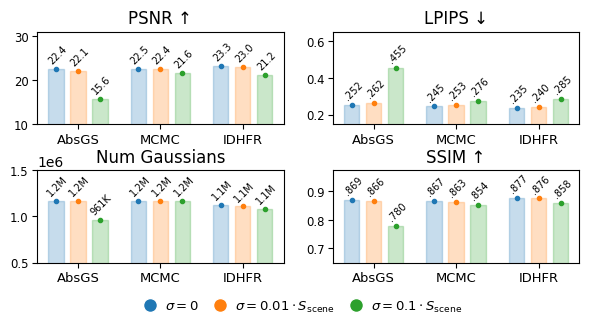

Dataset: eval_on_train_set_scannet++
Common scenes (15): eval_on_train_set_scannet++/5748ce6f01, eval_on_train_set_scannet++/9071e139d9, eval_on_train_set_scannet++/7831862f02, eval_on_train_set_scannet++/bcd2436daf, eval_on_train_set_scannet++/e7af285f7d, eval_on_train_set_scannet++/c5439f4607, eval_on_train_set_scannet++/3db0a1c8f3, eval_on_train_set_scannet++/b0a08200c9, eval_on_train_set_scannet++/825d228aec, eval_on_train_set_scannet++/bde1e479ad, eval_on_train_set_scannet++/6115eddb86, eval_on_train_set_scannet++/3f15a9266d, eval_on_train_set_scannet++/5eb31827b7, eval_on_train_set_scannet++/f3d64c30f8, eval_on_train_set_scannet++/40aec5fffa
Saved: graphs/gt_noise_resiliency/eval_on_train_set_scannetpp_absolute.svg


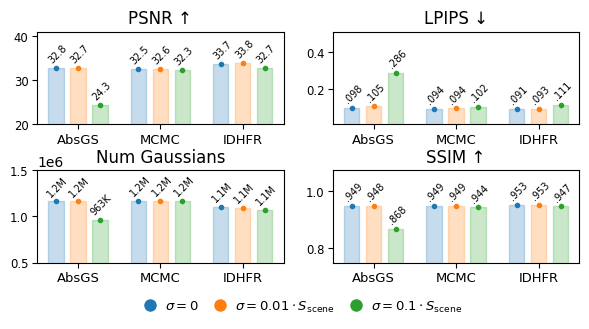

Dataset: eth3d
Common scenes (7): eth3d/terrains, eth3d/relief, eth3d/office, eth3d/pipes, eth3d/terrace, eth3d/kicker, eth3d/relief_2
Saved: graphs/gt_noise_resiliency/eth3d_absolute.svg


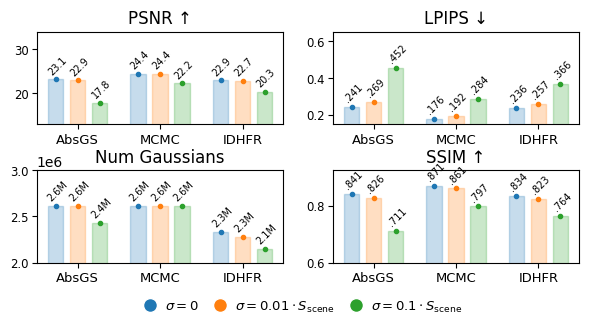

In [ ]:
# Resiliency of densification to noise at init size fraction 0.5
from eval_scripts.results_processing.base import (
    TABLE_METRICS,
    drop_scenes_not_present_in_all,
)
from matplotlib import pyplot as plt
from eval_scripts.results_processing.plots import (
    grouped_per_metric_barplots_for_each_config,
)


common_args = {
    "is_default_strategy_config": True,
    "init_size_matches_gmax": True,
    "dense_init.target_points_fraction": "0.5",
    "gaussian_cap_fraction": "1.0",
    "init_method": "laser_scan",
}


def noise_name(noise: str | float) -> str:
    noise_float = float(noise)
    if noise_float == 0.0:
        return "$\\sigma = 0$"
    return f"$\\sigma = {noise_float} \\cdot S_\\text{{scene}}$"


CELL_GRAPH_SUBDIR = "gt_noise_resiliency"
for dataset in GT_DATASETS:
    print("Dataset:", dataset)
    runs = runs_per_dataset[dataset]
    data = {}

    for noise in ["0.0", "0.01", "0.1"]:
        for strategy in [
            "DefaultWithGaussianCapStrategy",
            # "DefaultWithoutADCStrategy",
            "MCMCStrategy",
            "IDHFRStrategy",
        ]:
            args = {
                **common_args,
                "strategy": strategy,
                "init.position_noise_std": noise,
            }
            x = runs.get_per_scene_metrics_for_params(args)
            strat_name = STRATEGY_NAMES[strategy]
            data.setdefault(strat_name, {})[noise_name(noise)] = x

    all_dfs = [x for g in data.values() for x in g.values()]
    drop_scenes_not_present_in_all(*all_dfs)

    data = {
        strat_name: {noise: df.mean() for noise, df in noise_dict.items()}
        for strat_name, noise_dict in data.items()
    }

    plot_ranges_per_metric = {
        "eval-all-test/psnr": 21,
        "eval-all-test/ssim": 0.325,
        "eval-all-test/lpips": 0.5,
        "train/total-train-time": 10,
        "train/num-gaussians": 1e6,
    }
    plot_starts_per_metric_per_dataset = {
        "eth3d": {
            "eval-all-test/psnr": 13,
            "eval-all-test/ssim": 0.6,
            "eval-all-test/lpips": 0.15,
            "train/total-train-time": 7,
            "train/num-gaussians": 2e6,
        },
        "scannet++": {
            "eval-all-test/psnr": 10,
            "eval-all-test/ssim": 0.65,
            "eval-all-test/lpips": 0.15,
            "train/total-train-time": 7,
            "train/num-gaussians": 0.5e6,
        },
        "eval_on_train_set_scannet++": {
            "eval-all-test/psnr": 20,
            "eval-all-test/ssim": 0.75,
            "eval-all-test/lpips": 0.01,
            "train/total-train-time": 7,
            "train/num-gaussians": 0.5e6,
        },
    }

    plot_limits = {
        metric: (
            plot_starts_per_metric_per_dataset[dataset][metric],
            plot_starts_per_metric_per_dataset[dataset][metric]
            + plot_ranges_per_metric[metric],
        )
        for metric in TABLE_METRICS
    }

    fig, axes, _ = grouped_per_metric_barplots_for_each_config(
        data,
        metrics_to_plot=[
            "eval-all-test/psnr",
            "eval-all-test/lpips",
            "train/num-gaussians",
            "eval-all-test/ssim",
        ],
        figsize=(7, 3),
        plot_limits_per_metric=plot_limits,
        rotate_bar_labels_angle=45,
        label_all_bars=True,
        legend_y_offset=0.1,
        font_scale=1.35,
    )
    save_figure_svg(fig, CELL_GRAPH_SUBDIR, f"{dataset}_absolute")
    plt.show()

Dataset: scannet++
Common scenes (15): scannet++/3f15a9266d, scannet++/40aec5fffa, scannet++/c5439f4607, scannet++/6115eddb86, scannet++/5eb31827b7, scannet++/bcd2436daf, scannet++/e7af285f7d, scannet++/f3d64c30f8, scannet++/825d228aec, scannet++/5748ce6f01, scannet++/b0a08200c9, scannet++/3db0a1c8f3, scannet++/9071e139d9, scannet++/7831862f02, scannet++/bde1e479ad


/tmp/ipykernel_2018/3614941478.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: graphs/edgs_monodepth_vs_gt/scannetpp_main.svg


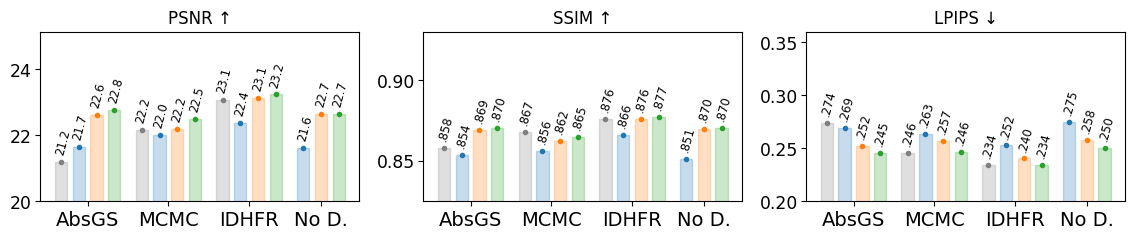

Dataset: eval_on_train_set_scannet++
Common scenes (15): eval_on_train_set_scannet++/bcd2436daf, eval_on_train_set_scannet++/9071e139d9, eval_on_train_set_scannet++/5748ce6f01, eval_on_train_set_scannet++/c5439f4607, eval_on_train_set_scannet++/e7af285f7d, eval_on_train_set_scannet++/7831862f02, eval_on_train_set_scannet++/3db0a1c8f3, eval_on_train_set_scannet++/b0a08200c9, eval_on_train_set_scannet++/bde1e479ad, eval_on_train_set_scannet++/825d228aec, eval_on_train_set_scannet++/6115eddb86, eval_on_train_set_scannet++/3f15a9266d, eval_on_train_set_scannet++/5eb31827b7, eval_on_train_set_scannet++/f3d64c30f8, eval_on_train_set_scannet++/40aec5fffa


/tmp/ipykernel_2018/3614941478.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: graphs/edgs_monodepth_vs_gt/eval_on_train_set_scannetpp_main.svg


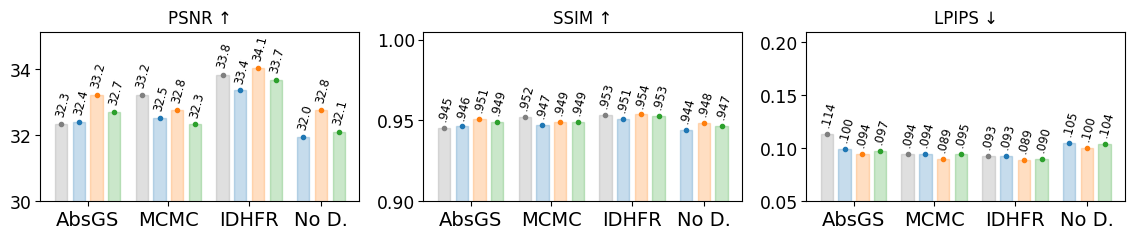

Dataset: tanksandtemples
Common scenes (14): tanksandtemples/train, tanksandtemples/truck, tanksandtemples/auditorium, tanksandtemples/horse, tanksandtemples/temple, tanksandtemples/family, tanksandtemples/church, tanksandtemples/m60, tanksandtemples/caterpillar, tanksandtemples/palace, tanksandtemples/meetingroom, tanksandtemples/barn, tanksandtemples/lighthouse, tanksandtemples/ballroom
Saved: graphs/edgs_monodepth_vs_gt/tanksandtemples_main.svg


/tmp/ipykernel_2018/3614941478.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


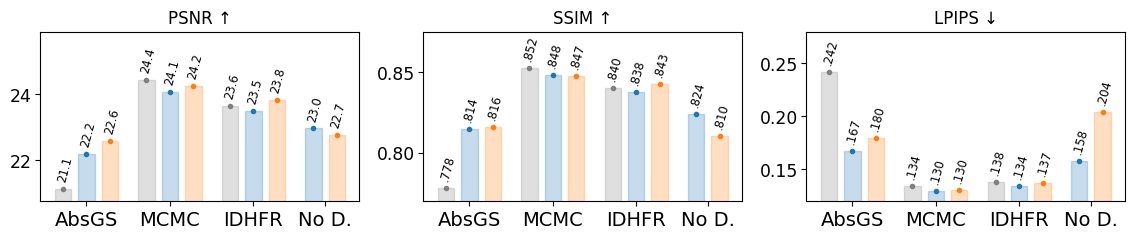

Dataset: mipnerf360
Common scenes (9): mipnerf360/treehill, mipnerf360/room, mipnerf360/bonsai, mipnerf360/flowers, mipnerf360/bicycle, mipnerf360/kitchen, mipnerf360/stump, mipnerf360/counter, mipnerf360/garden


/tmp/ipykernel_2018/3614941478.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: graphs/edgs_monodepth_vs_gt/mipnerf360_main.svg


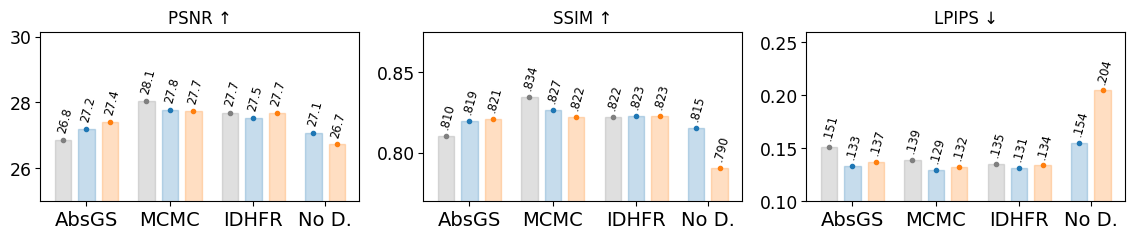

Saved: graphs/edgs_monodepth_vs_gt/legend_main.svg
EDGS mean init time (all datasets): 102.55s
Monodepth mean init time (all datasets): 98.68s


<Figure size 600x100 with 0 Axes>

In [ ]:
# Monodepth/EDGS vs GT
import pandas as pd
from eval_scripts.results_processing.base import (
    TABLE_METRICS,
    drop_scenes_not_present_in_all,
    load_init_method_runs,
)
from eval_scripts.results_processing.plots import (
    grouped_per_metric_barplots_for_each_config,
)
import matplotlib.pyplot as plt

monodepth_init_runs = load_init_method_runs(experiment_name="monodepth_init")
edgs_init_runs = load_init_method_runs(experiment_name="edgs_init")

EDGS_LABEL = "$EDGS^*$"
MONODEPTH_LABEL = "Monocular Depth"
GT_LABEL = "Laser Init. of same size"
CELL_GRAPH_SUBDIR = "edgs_monodepth_vs_gt"

datasets = ALL_DATASETS_WITHOUT_ETH3D

edgs_init_sum = 0
edgs_init_count = 0
monodepth_init_sum = 0
monodepth_init_count = 0
for i, dataset in enumerate(datasets):
    is_last = i == len(datasets) - 1
    print("Dataset:", dataset)
    runs = runs_per_dataset[dataset]

    common_args = {
        "is_default_strategy_config": True,
        "gaussian_cap_fraction": "1.0",
        "init.position_noise_std": "0.0",
    }

    sfm = runs.get_per_scene_metrics_for_params(
        {
            **common_args,
            "init_group": "sfm_baseline",
            "strategy": "DefaultWithGaussianCapStrategy",
        },
    )
    sfm_mcmc = runs.get_per_scene_metrics_for_params(
        {
            **common_args,
            "init_group": "sfm_baseline",
            "strategy": "MCMCStrategy",
        },
    )
    sfm_idhfr = runs.get_per_scene_metrics_for_params(
        {
            **common_args,
            "init_group": "sfm_baseline",
            "strategy": "IDHFRStrategy",
        },
    )

    data = {}
    for strategy in [
        "DefaultWithoutADCStrategy",
        "DefaultWithGaussianCapStrategy",
        "MCMCStrategy",
        "IDHFRStrategy",
    ]:
        edgs_params = {
            **common_args,
            "strategy": strategy,
            "init_method": "edgs",
            "splat_init.increase_scale_with_fewer_splats": True,
        }
        monodepth_params = {
            **common_args,
            "strategy": strategy,
            "init_method": "monodepth",
        }
        edgs_runs = runs.get_runs_with_params(edgs_params)
        monodepth_runs = runs.get_runs_with_params(monodepth_params)

        edgs = edgs_runs.get_per_scene_metrics_for_params({})
        monodepth = monodepth_runs.get_per_scene_metrics_for_params({})

        strat_name = STRATEGY_NAMES[strategy]
        data.setdefault(strat_name, {})[EDGS_LABEL] = edgs
        data.setdefault(strat_name, {})[MONODEPTH_LABEL] = monodepth

        if dataset in GT_DATASETS:
            data.setdefault(strat_name, {})[GT_LABEL] = (
                runs.get_per_scene_metrics_for_params(
                    {
                        **common_args,
                        "strategy": strategy,
                        "init_method": "laser_scan",
                        "init_size_matches_real_init": True,
                        "dense_init.target_points_fraction": "1.0",
                    }
                )
            )

    all_dfs = [x for strat_dict in data.values() for x in strat_dict.values()]
    drop_scenes_not_present_in_all(sfm, sfm_mcmc, *all_dfs)

    data_means = {}
    data_means["AbsGS"] = {"SfM (Size differs)": sfm.mean()}
    data_means["MCMC"] = {"SfM (Size differs)": sfm_mcmc.mean()}
    data_means["IDHFR"] = {"SfM (Size differs)": sfm_idhfr.mean()}

    for strat, method_dict in data.items():
        for method, df in method_dict.items():
            data_means.setdefault(strat, {})[method] = df.mean()

    plot_ranges_per_metric = {
        "eval-all-test/psnr": 5.15,
        "eval-all-test/ssim": 0.105,
        "eval-all-test/lpips": 0.16,
    }
    plot_starts_per_metric_per_dataset = {
        "scannet++": {
            "eval-all-test/psnr": 20,
            "eval-all-test/ssim": 0.825,
            "eval-all-test/lpips": 0.2,
        },
        "eval_on_train_set_scannet++": {
            "eval-all-test/psnr": 30.0,
            "eval-all-test/ssim": 0.9,
            "eval-all-test/lpips": 0.05,
        },
        "mipnerf360": {
            "eval-all-test/psnr": 25.0,
            "eval-all-test/ssim": 0.77,
            "eval-all-test/lpips": 0.1,
        },
        "tanksandtemples": {
            "eval-all-test/psnr": 20.75,
            "eval-all-test/ssim": 0.77,
            "eval-all-test/lpips": 0.12,
        },
    }

    plot_limits_per_metric = {
        metric: (
            plot_starts_per_metric_per_dataset.get(dataset, {}).get(metric, 0),
            plot_starts_per_metric_per_dataset.get(dataset, {}).get(metric, 0)
            + range_val,
        )
        for metric, range_val in plot_ranges_per_metric.items()
    }

    init_method_cmap = plt.cm.tab10

    fig, axes, (handles, labels) = grouped_per_metric_barplots_for_each_config(
        data_means,
        metrics_to_plot=[
            m
            for m in TABLE_METRICS
            if m not in {"train/num-gaussians", "train/total-train-time"}
        ],
        figsize=(14, 2.2),
        label_all_bars=True,
        plot_limits_per_metric=plot_limits_per_metric,
        columns=3,
        rotate_labels_angle=45,
        rotate_all_labels=False,
        rotate_bar_labels_angle=75,
        bar_labels_font_scale=1.2,
        padding_factor=0.55 if "scannet++" in dataset else 0.75,
        legend_y_offset=0.2,
        colors=["gray"] + list(init_method_cmap.colors),
        show_legend=False,
        font_scale=2,
    )

    plt.tight_layout()
    save_figure_svg(fig, CELL_GRAPH_SUBDIR, f"{dataset}_main")
    plt.show()

    if is_last:
        # Save legend
        fig = plt.figure(figsize=(6, 1))

        legend = fig.legend(
            handles,
            labels,
            loc="center",
            ncol=len(handles),
            columnspacing=0.25,
            handletextpad=0.15,
            frameon=False,
        )

        # Draw the figure so legend gets a size
        fig.canvas.draw()

        # Save ONLY the legend
        bbox = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
        save_figure_svg(fig, CELL_GRAPH_SUBDIR, "legend_main", bbox_inches=bbox)

edgs_mean_init_time = edgs_init_runs.df["init_only_runtime"].mean()
monodepth_mean_init_time = monodepth_init_runs.df["init_only_runtime"].mean()

print(f"EDGS mean init time (all datasets): {edgs_mean_init_time:.2f}s")
print(f"Monodepth mean init time (all datasets): {monodepth_mean_init_time:.2f}s")

========== Init method: laser_scan ==========
Dataset: scannet++
Common scenes (15): scannet++/3f15a9266d, scannet++/40aec5fffa, scannet++/5eb31827b7, scannet++/c5439f4607, scannet++/6115eddb86, scannet++/bcd2436daf, scannet++/e7af285f7d, scannet++/f3d64c30f8, scannet++/5748ce6f01, scannet++/825d228aec, scannet++/b0a08200c9, scannet++/3db0a1c8f3, scannet++/9071e139d9, scannet++/7831862f02, scannet++/bde1e479ad
Saved: graphs/gaussian_cap_fractions/gt/scannetpp_cap_fraction_gt.svg


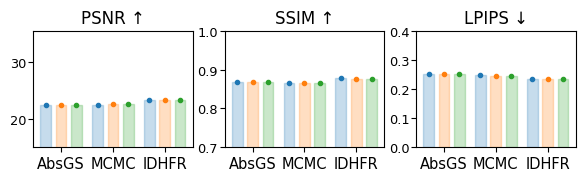

Dataset: eval_on_train_set_scannet++
Common scenes (15): eval_on_train_set_scannet++/5748ce6f01, eval_on_train_set_scannet++/9071e139d9, eval_on_train_set_scannet++/7831862f02, eval_on_train_set_scannet++/c5439f4607, eval_on_train_set_scannet++/e7af285f7d, eval_on_train_set_scannet++/bcd2436daf, eval_on_train_set_scannet++/3db0a1c8f3, eval_on_train_set_scannet++/b0a08200c9, eval_on_train_set_scannet++/825d228aec, eval_on_train_set_scannet++/3f15a9266d, eval_on_train_set_scannet++/6115eddb86, eval_on_train_set_scannet++/bde1e479ad, eval_on_train_set_scannet++/5eb31827b7, eval_on_train_set_scannet++/f3d64c30f8, eval_on_train_set_scannet++/40aec5fffa
Saved: graphs/gaussian_cap_fractions/gt/eval_on_train_set_scannetpp_cap_fraction_gt.svg


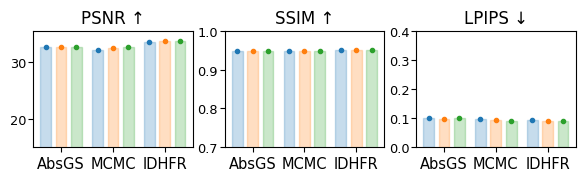

Dataset: eth3d
Common scenes (7): eth3d/terrains, eth3d/relief, eth3d/office, eth3d/pipes, eth3d/terrace, eth3d/kicker, eth3d/relief_2
Saved: graphs/gaussian_cap_fractions/gt/eth3d_cap_fraction_gt.svg


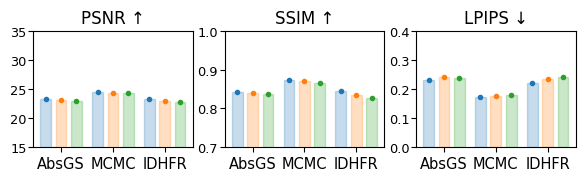

========== Init method: sfm ==========
Dataset: scannet++
Common scenes (15): scannet++/3f15a9266d, scannet++/40aec5fffa, scannet++/5eb31827b7, scannet++/c5439f4607, scannet++/6115eddb86, scannet++/bcd2436daf, scannet++/e7af285f7d, scannet++/f3d64c30f8, scannet++/5748ce6f01, scannet++/825d228aec, scannet++/b0a08200c9, scannet++/3db0a1c8f3, scannet++/9071e139d9, scannet++/7831862f02, scannet++/bde1e479ad
Saved: graphs/gaussian_cap_fractions/gt/scannetpp_cap_fraction_gt.svg


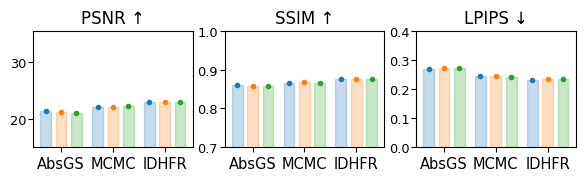

Dataset: eval_on_train_set_scannet++
Common scenes (15): eval_on_train_set_scannet++/5748ce6f01, eval_on_train_set_scannet++/9071e139d9, eval_on_train_set_scannet++/7831862f02, eval_on_train_set_scannet++/c5439f4607, eval_on_train_set_scannet++/e7af285f7d, eval_on_train_set_scannet++/bcd2436daf, eval_on_train_set_scannet++/3db0a1c8f3, eval_on_train_set_scannet++/b0a08200c9, eval_on_train_set_scannet++/825d228aec, eval_on_train_set_scannet++/bde1e479ad, eval_on_train_set_scannet++/6115eddb86, eval_on_train_set_scannet++/3f15a9266d, eval_on_train_set_scannet++/5eb31827b7, eval_on_train_set_scannet++/f3d64c30f8, eval_on_train_set_scannet++/40aec5fffa
Saved: graphs/gaussian_cap_fractions/gt/eval_on_train_set_scannetpp_cap_fraction_gt.svg


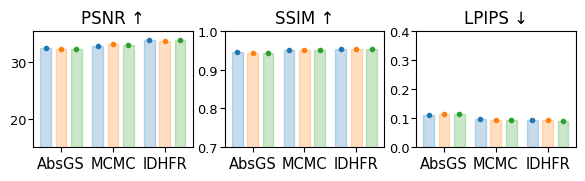

Dataset: eth3d
Common scenes (7): eth3d/terrains, eth3d/relief, eth3d/office, eth3d/pipes, eth3d/terrace, eth3d/kicker, eth3d/relief_2
Saved: graphs/gaussian_cap_fractions/gt/eth3d_cap_fraction_gt.svg


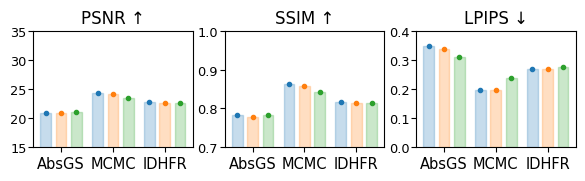

In [ ]:
# Different G_max fractions with laser scan init at 50% G_max init size, and SfM init
# TODO: Forgot to specify GT init size in paper.

from eval_scripts.results_processing.base import (
    drop_scenes_not_present_in_all,
)
from eval_scripts.results_processing.plots import (
    grouped_per_metric_barplots_for_each_config,
)
import pandas as pd
import matplotlib.pyplot as plt

# strategy: cap_fraction: data
data: dict[str, dict[float, pd.DataFrame]] = {}
CELL_GRAPH_SUBDIR = "gaussian_cap_fractions/gt"

init_method_args = {
    "laser_scan": {
        "init_method": "laser_scan",
        "init_size_matches_gmax": True,
        "dense_init.target_points_fraction": "0.5",
    },
    "sfm": {
        # "init_group": "sfm_baseline",
        "init_method": "sfm",
    },
}

for init_method in ["laser_scan", "sfm"]:
    print("========== Init method:", init_method, "==========")
    for dataset in GT_DATASETS:
        print("Dataset:", dataset)
        runs = runs_per_dataset[dataset]

        for strategy in [
            "DefaultWithGaussianCapStrategy",
            "MCMCStrategy",
            "IDHFRStrategy",
        ]:
            strategy_common = {
                "is_default_strategy_config": True,
                "strategy": strategy,
                "init.position_noise_std": "0.0",
                **init_method_args[init_method],
            }

            for cap_fraction in ["0.75", "1.0", "1.25"]:
                metrics_for_cap = runs.get_per_scene_metrics_for_params(
                    {**strategy_common, "gaussian_cap_fraction": cap_fraction},
                )
                cap_fraction_name = (
                    f"{float(cap_fraction)*100:.0f}% $G_\\mathit{{max}}$"
                )
                data.setdefault(STRATEGY_NAMES[strategy], {})[
                    cap_fraction_name
                ] = metrics_for_cap

        all_dataframes = [
            x for strategy_dict in data.values() for x in strategy_dict.values()
        ]
        drop_scenes_not_present_in_all(*all_dataframes)

        data_means = {
            strategy: {cap_fraction: df.mean() for cap_fraction, df in cap_dict.items()}
            for strategy, cap_dict in data.items()
        }
        fig, axes, _ = grouped_per_metric_barplots_for_each_config(
            data_means,
            metrics_to_plot=[
                "eval-all-test/psnr",
                "eval-all-test/ssim",
                "eval-all-test/lpips",
            ],
            plot_limits_per_metric=PLOT_RANGES_PER_METRIC[dataset],
            label_all_bars=False,
            columns=3,
            figsize=(7, 1.5),
            legend_y_offset=0.15,
            padding_factor=0.5,
            show_legend=False,
            font_scale=1.5,
            y_ticks_pad_scale=0.5,
        )

        save_figure_svg(fig, CELL_GRAPH_SUBDIR, f"{dataset}_cap_fraction_gt")
        plt.show()

Dataset: scannet++
Scenes SfM: [total: 15] ['scannet++/3db0a1c8f3', 'scannet++/3f15a9266d', 'scannet++/40aec5fffa', 'scannet++/5748ce6f01', 'scannet++/5eb31827b7', 'scannet++/6115eddb86', 'scannet++/7831862f02', 'scannet++/825d228aec', 'scannet++/9071e139d9', 'scannet++/b0a08200c9', 'scannet++/bcd2436daf', 'scannet++/bde1e479ad', 'scannet++/c5439f4607', 'scannet++/e7af285f7d', 'scannet++/f3d64c30f8']
Scenes SfM MCMC (0.0005): [total: 15] ['scannet++/3db0a1c8f3', 'scannet++/3f15a9266d', 'scannet++/40aec5fffa', 'scannet++/5748ce6f01', 'scannet++/5eb31827b7', 'scannet++/6115eddb86', 'scannet++/7831862f02', 'scannet++/825d228aec', 'scannet++/9071e139d9', 'scannet++/b0a08200c9', 'scannet++/bcd2436daf', 'scannet++/bde1e479ad', 'scannet++/c5439f4607', 'scannet++/e7af285f7d', 'scannet++/f3d64c30f8']
Scenes SfM MCMC (default): [total: 15] ['scannet++/3db0a1c8f3', 'scannet++/3f15a9266d', 'scannet++/40aec5fffa', 'scannet++/5748ce6f01', 'scannet++/5eb31827b7', 'scannet++/6115eddb86', 'scannet++/78

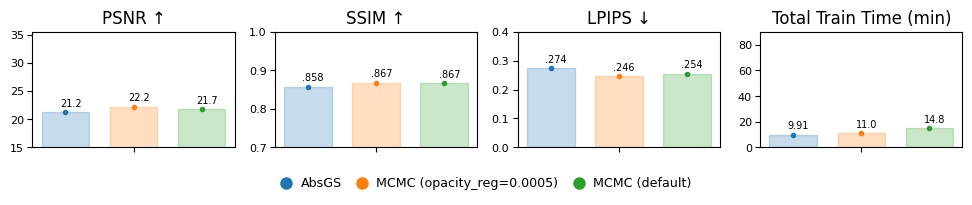

Dataset: eval_on_train_set_scannet++
Scenes SfM: [total: 15] ['eval_on_train_set_scannet++/3db0a1c8f3', 'eval_on_train_set_scannet++/3f15a9266d', 'eval_on_train_set_scannet++/40aec5fffa', 'eval_on_train_set_scannet++/5748ce6f01', 'eval_on_train_set_scannet++/5eb31827b7', 'eval_on_train_set_scannet++/6115eddb86', 'eval_on_train_set_scannet++/7831862f02', 'eval_on_train_set_scannet++/825d228aec', 'eval_on_train_set_scannet++/9071e139d9', 'eval_on_train_set_scannet++/b0a08200c9', 'eval_on_train_set_scannet++/bcd2436daf', 'eval_on_train_set_scannet++/bde1e479ad', 'eval_on_train_set_scannet++/c5439f4607', 'eval_on_train_set_scannet++/e7af285f7d', 'eval_on_train_set_scannet++/f3d64c30f8']
Scenes SfM MCMC (0.0005): [total: 15] ['eval_on_train_set_scannet++/3db0a1c8f3', 'eval_on_train_set_scannet++/3f15a9266d', 'eval_on_train_set_scannet++/40aec5fffa', 'eval_on_train_set_scannet++/5748ce6f01', 'eval_on_train_set_scannet++/5eb31827b7', 'eval_on_train_set_scannet++/6115eddb86', 'eval_on_train_se

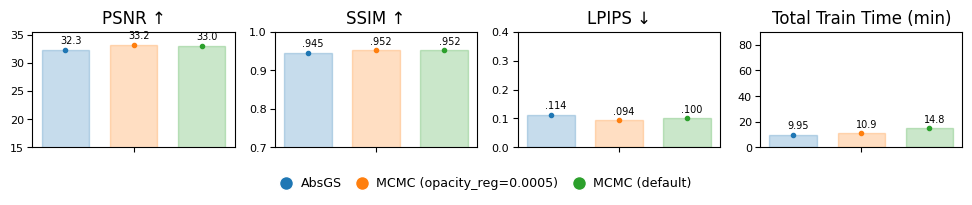

In [ ]:
# MCMC Opacity regularization ablation.
from matplotlib import pyplot as plt
from eval_scripts.results_processing.base import (
    drop_scenes_not_present_in_all,
)
from eval_scripts.results_processing.plots import (
    grouped_per_metric_barplots_for_each_config,
)

common_args = {
    "gaussian_cap_fraction": "1.0",
}
CELL_GRAPH_SUBDIR = "mcmc_opacity_reg_choice"

for dataset in ["scannet++", "eval_on_train_set_scannet++"]:
    print("Dataset:", dataset)
    runs = runs_per_dataset[dataset]
    sfm = runs.get_per_scene_metrics_for_params(
        {
            **common_args,
            "init_method": "sfm",
            "is_default_strategy_config": True,
            "strategy": "DefaultWithGaussianCapStrategy",
        },
    )

    sfm_mcmc = runs.get_per_scene_metrics_for_params(
        {
            **common_args,
            "init_method": "sfm",
            "is_default_strategy_config": True,
            "strategy": "MCMCStrategy",
        },
    )
    sfm_mcmc_default_opacity_reg = runs.get_per_scene_metrics_for_params(
        {
            **common_args,
            "init_method": "sfm",
            "strategy": "MCMCStrategy",
            "opacity_reg": "0.01",
        }
    )

    print("Scenes SfM:", f"[total: {len(sfm.index)}]", sorted(sfm.index.tolist()))
    print(
        "Scenes SfM MCMC (0.0005):",
        f"[total: {len(sfm_mcmc.index)}]",
        sorted(sfm_mcmc.index.tolist()),
    )
    print(
        "Scenes SfM MCMC (default):",
        f"[total: {len(sfm_mcmc_default_opacity_reg.index)}]",
        sorted(sfm_mcmc_default_opacity_reg.index.tolist()),
    )

    drop_scenes_not_present_in_all(sfm, sfm_mcmc, sfm_mcmc_default_opacity_reg)

    fig, axes, _ = grouped_per_metric_barplots_for_each_config(
        {
            "": {
                "AbsGS": sfm.mean(),
                "MCMC (opacity_reg=0.0005)": sfm_mcmc.mean(),
                "MCMC (default)": sfm_mcmc_default_opacity_reg.mean(),
            }
        },
        # additional_data={"SfM": sfm.mean(), "MCMC": sfm_mcmc.mean()},
        metrics_to_plot=[
            "eval-all-test/psnr",
            "eval-all-test/ssim",
            "eval-all-test/lpips",
            "train/total-train-time",
        ],
        label_all_bars=True,
        plot_limits_per_metric=PLOT_RANGES_PER_METRIC[dataset],
        columns=4,
        figsize=(12, 1.5),
        padding_factor=0.75,
        font_scale=1.3,
        legend_y_offset=0.125,
    )

    save_figure_svg(fig, CELL_GRAPH_SUBDIR, f"{dataset}_opacity_reg_comparison")
    plt.show()

In [ ]:
# Scale increase for subsampled EDGS init ablation
from eval_scripts.results_processing.base import (
    drop_scenes_not_present_in_all,
)
import pandas as pd

CELL_GRAPH_SUBDIR = "mcmc_opacity_reg_choice"

# Optional pretty names for columns
metric_name_map = {
    "eval-all-test/psnr": "PSNR",
    "eval-all-test/ssim": "SSIM",
    "eval-all-test/lpips": "LPIPS",
    "train/num-gaussians": "#Gaussians",
    "train/total-train-time": "Train Time",
}

rows = []

for dataset in ALL_DATASETS_WITHOUT_ETH3D:
    runs = runs_per_dataset[dataset]

    all_for_dataset = []
    all_for_dataset_scale_increase = []
    for strategy in ["DefaultWithGaussianCapStrategy", "MCMCStrategy", "IDHFRStrategy"]:
        strategy_args = {
            "init_method": "edgs",
            "gaussian_cap_fraction": "1.0",
            "strategy": strategy,
            "is_default_strategy_config": True,
        }

        edgs = runs.get_per_scene_metrics_for_params(
            {
                **strategy_args,
                "splat_init.increase_scale_with_fewer_splats": False,
            },
        )
        edgs_with_scale_increase = runs.get_per_scene_metrics_for_params(
            {
                **strategy_args,
                "splat_init.increase_scale_with_fewer_splats": True,
            },
        )

        all_for_dataset.append(edgs)
        all_for_dataset_scale_increase.append(edgs_with_scale_increase)

    drop_scenes_not_present_in_all(*all_for_dataset, *all_for_dataset_scale_increase)

    # Aggregate across strategies + scenes
    edgs_all = pd.concat(all_for_dataset, axis=0, ignore_index=True)
    edgs_si_all = pd.concat(all_for_dataset_scale_increase, axis=0, ignore_index=True)

    row = {"Dataset": dataset}
    for metric in ["eval-all-test/psnr", "eval-all-test/ssim", "eval-all-test/lpips"]:
        pretty = metric_name_map.get(metric, metric)
        row[pretty] = pd.to_numeric(edgs_all[metric], errors="raise").mean()
        row[f"{pretty} (Scale Increase)"] = pd.to_numeric(
            edgs_si_all[metric], errors="raise"
        ).mean()

    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("Dataset")
display(summary_df)
print(summary_df.to_latex(float_format="%.3f"))

Common scenes (15): scannet++/3f15a9266d, scannet++/40aec5fffa, scannet++/5eb31827b7, scannet++/c5439f4607, scannet++/6115eddb86, scannet++/bcd2436daf, scannet++/e7af285f7d, scannet++/f3d64c30f8, scannet++/5748ce6f01, scannet++/825d228aec, scannet++/9071e139d9, scannet++/b0a08200c9, scannet++/3db0a1c8f3, scannet++/7831862f02, scannet++/bde1e479ad
Common scenes (15): eval_on_train_set_scannet++/bcd2436daf, eval_on_train_set_scannet++/9071e139d9, eval_on_train_set_scannet++/5748ce6f01, eval_on_train_set_scannet++/c5439f4607, eval_on_train_set_scannet++/e7af285f7d, eval_on_train_set_scannet++/7831862f02, eval_on_train_set_scannet++/3db0a1c8f3, eval_on_train_set_scannet++/b0a08200c9, eval_on_train_set_scannet++/bde1e479ad, eval_on_train_set_scannet++/825d228aec, eval_on_train_set_scannet++/6115eddb86, eval_on_train_set_scannet++/3f15a9266d, eval_on_train_set_scannet++/5eb31827b7, eval_on_train_set_scannet++/f3d64c30f8, eval_on_train_set_scannet++/40aec5fffa
Common scenes (14): tanksandtemp

,PSNR,PSNR (Scale Increase),SSIM,SSIM (Scale Increase),LPIPS,LPIPS (Scale Increase)
Dataset,,,,,,
scannet++,21.907851,22.006471,0.857832,0.858678,0.263302,0.261556
eval_on_train_set_scannet++,32.759079,32.766819,0.947975,0.948184,0.096334,0.095609
tanksandtemples,23.192561,23.239938,0.830642,0.833347,0.146470,0.143831
mipnerf360,27.469380,27.494293,0.821993,0.822902,0.131324,0.131213


\begin{tabular}{lrrrrrr}
\toprule
 & PSNR & PSNR (Scale Increase) & SSIM & SSIM (Scale Increase) & LPIPS & LPIPS (Scale Increase) \\
Dataset &  &  &  &  &  &  \\
\midrule
scannet++ & 21.908 & 22.006 & 0.858 & 0.859 & 0.263 & 0.262 \\
eval_on_train_set_scannet++ & 32.759 & 32.767 & 0.948 & 0.948 & 0.096 & 0.096 \\
tanksandtemples & 23.193 & 23.240 & 0.831 & 0.833 & 0.146 & 0.144 \\
mipnerf360 & 27.469 & 27.494 & 0.822 & 0.823 & 0.131 & 0.131 \\
\bottomrule
\end{tabular}



In [ ]:
# IDHFR Means LR adjustment ablation
from eval_scripts.results_processing.base import (
    drop_scenes_not_present_in_all,
)
import pandas as pd

# Optional pretty names for columns
metric_name_map = {
    "eval-all-test/psnr": "PSNR",
    "eval-all-test/ssim": "SSIM",
    "eval-all-test/lpips": "LPIPS",
    "train/num-gaussians": "#Gaussians",
    "train/total-train-time": "Train Time",
}

rows = []

for dataset in ALL_DATASETS:
    runs = runs_per_dataset[dataset]

    strategy_args = {
        "init_method": "sfm",
        "gaussian_cap_fraction": "1.0",
        **get_default_strategy_args("IDHFRStrategy", dataset),
    }

    base = runs.get_per_scene_metrics_for_params(
        {
            **strategy_args,
            "is_default_strategy_config": True,
        },
    )
    lr_change = runs.get_per_scene_metrics_for_params(
        {**strategy_args, "means_lr_init": "4e-05"},
    )

    drop_scenes_not_present_in_all(base, lr_change)

    row = {"Dataset": dataset}
    for metric in ["eval-all-test/psnr", "eval-all-test/ssim", "eval-all-test/lpips"]:
        pretty = metric_name_map.get(metric, metric)
        row[pretty] = pd.to_numeric(base[metric], errors="raise").mean()
        row[f"{pretty} (LR)"] = pd.to_numeric(lr_change[metric], errors="raise").mean()

    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("Dataset")
display(summary_df)
print(summary_df.to_latex(float_format="%.3f"))

Common scenes (15): scannet++/3f15a9266d, scannet++/40aec5fffa, scannet++/c5439f4607, scannet++/5eb31827b7, scannet++/6115eddb86, scannet++/bcd2436daf, scannet++/e7af285f7d, scannet++/f3d64c30f8, scannet++/5748ce6f01, scannet++/825d228aec, scannet++/b0a08200c9, scannet++/9071e139d9, scannet++/3db0a1c8f3, scannet++/7831862f02, scannet++/bde1e479ad
Common scenes (15): eval_on_train_set_scannet++/5748ce6f01, eval_on_train_set_scannet++/9071e139d9, eval_on_train_set_scannet++/e7af285f7d, eval_on_train_set_scannet++/bcd2436daf, eval_on_train_set_scannet++/7831862f02, eval_on_train_set_scannet++/c5439f4607, eval_on_train_set_scannet++/3db0a1c8f3, eval_on_train_set_scannet++/b0a08200c9, eval_on_train_set_scannet++/3f15a9266d, eval_on_train_set_scannet++/825d228aec, eval_on_train_set_scannet++/bde1e479ad, eval_on_train_set_scannet++/6115eddb86, eval_on_train_set_scannet++/5eb31827b7, eval_on_train_set_scannet++/f3d64c30f8, eval_on_train_set_scannet++/40aec5fffa
Common scenes (7): eth3d/terrain

,PSNR,PSNR (LR),SSIM,SSIM (LR),LPIPS,LPIPS (LR)
Dataset,,,,,,
scannet++,23.064192,22.980943,0.876029,0.876496,0.233995,0.232942
eval_on_train_set_scannet++,33.821707,33.792877,0.953182,0.953073,0.092581,0.093278
eth3d,22.604247,22.200860,0.814293,0.810809,0.270733,0.278803
mipnerf360,27.689149,27.841446,0.821781,0.832230,0.134889,0.132217
tanksandtemples,23.640965,23.763111,0.840032,0.843334,0.137701,0.134056


\begin{tabular}{lrrrrrr}
\toprule
 & PSNR & PSNR (LR) & SSIM & SSIM (LR) & LPIPS & LPIPS (LR) \\
Dataset &  &  &  &  &  &  \\
\midrule
scannet++ & 23.064 & 22.981 & 0.876 & 0.876 & 0.234 & 0.233 \\
eval_on_train_set_scannet++ & 33.822 & 33.793 & 0.953 & 0.953 & 0.093 & 0.093 \\
eth3d & 22.604 & 22.201 & 0.814 & 0.811 & 0.271 & 0.279 \\
mipnerf360 & 27.689 & 27.841 & 0.822 & 0.832 & 0.135 & 0.132 \\
tanksandtemples & 23.641 & 23.763 & 0.840 & 0.843 & 0.138 & 0.134 \\
\bottomrule
\end{tabular}



Dataset: tanksandtemples
Common scenes (14): tanksandtemples/train, tanksandtemples/truck, tanksandtemples/auditorium, tanksandtemples/horse, tanksandtemples/temple, tanksandtemples/family, tanksandtemples/church, tanksandtemples/m60, tanksandtemples/caterpillar, tanksandtemples/palace, tanksandtemples/meetingroom, tanksandtemples/barn, tanksandtemples/lighthouse, tanksandtemples/ballroom


/tmp/ipykernel_2018/3194445564.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: graphs/da3_edgs_monodepth/tanksandtemples_da3.svg


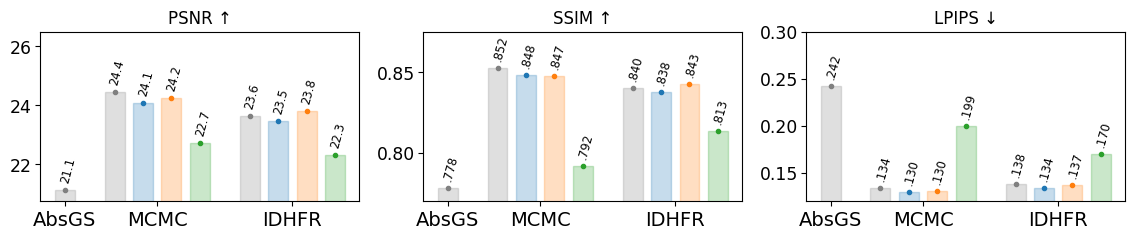

Dataset: scannet++


[09:33:40] root[WARNING]: Not all runs have the same scenes. Common scenes: 14, total unique scenes: 15
[09:33:40] root[WARNING]: Missing scenes per dataframe:
	Dataframe 4: {'scannet++/c5439f4607'}
	Dataframe 8: {'scannet++/c5439f4607'}
/tmp/ipykernel_2018/3194445564.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Common scenes (14): scannet++/3f15a9266d, scannet++/40aec5fffa, scannet++/5eb31827b7, scannet++/6115eddb86, scannet++/bcd2436daf, scannet++/e7af285f7d, scannet++/f3d64c30f8, scannet++/5748ce6f01, scannet++/825d228aec, scannet++/b0a08200c9, scannet++/9071e139d9, scannet++/3db0a1c8f3, scannet++/7831862f02, scannet++/bde1e479ad
Saved: graphs/da3_edgs_monodepth/scannetpp_da3.svg


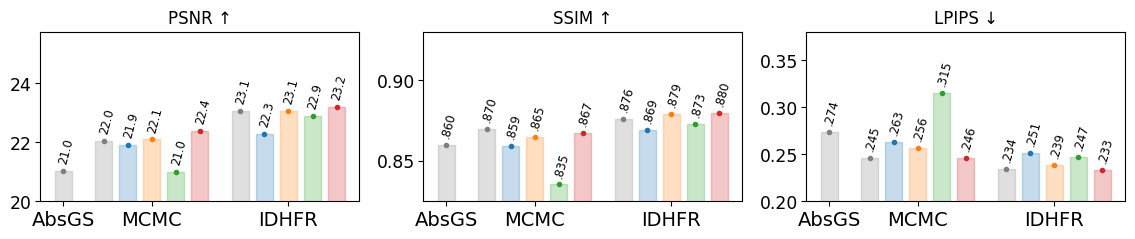

Dataset: mipnerf360
Common scenes (9): mipnerf360/treehill, mipnerf360/room, mipnerf360/bonsai, mipnerf360/flowers, mipnerf360/bicycle, mipnerf360/kitchen, mipnerf360/stump, mipnerf360/counter, mipnerf360/garden
Saved: graphs/da3_edgs_monodepth/mipnerf360_da3.svg


/tmp/ipykernel_2018/3194445564.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


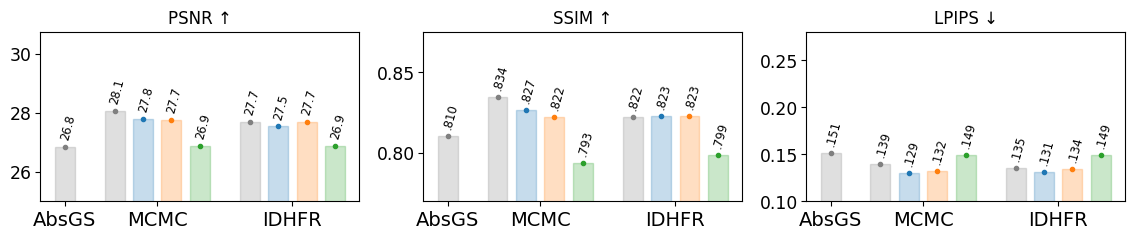

Dataset: eval_on_train_set_scannet++


[09:33:41] root[WARNING]: Not all runs have the same scenes. Common scenes: 12, total unique scenes: 15
[09:33:41] root[WARNING]: Missing scenes per dataframe:
	Dataframe 4: {'eval_on_train_set_scannet++/bde1e479ad', 'eval_on_train_set_scannet++/5eb31827b7', 'eval_on_train_set_scannet++/f3d64c30f8'}
	Dataframe 8: {'eval_on_train_set_scannet++/bde1e479ad', 'eval_on_train_set_scannet++/5eb31827b7', 'eval_on_train_set_scannet++/f3d64c30f8'}
/tmp/ipykernel_2018/3194445564.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Common scenes (12): eval_on_train_set_scannet++/5748ce6f01, eval_on_train_set_scannet++/9071e139d9, eval_on_train_set_scannet++/e7af285f7d, eval_on_train_set_scannet++/c5439f4607, eval_on_train_set_scannet++/bcd2436daf, eval_on_train_set_scannet++/7831862f02, eval_on_train_set_scannet++/3db0a1c8f3, eval_on_train_set_scannet++/b0a08200c9, eval_on_train_set_scannet++/3f15a9266d, eval_on_train_set_scannet++/825d228aec, eval_on_train_set_scannet++/6115eddb86, eval_on_train_set_scannet++/40aec5fffa
Saved: graphs/da3_edgs_monodepth/eval_on_train_set_scannetpp_da3.svg


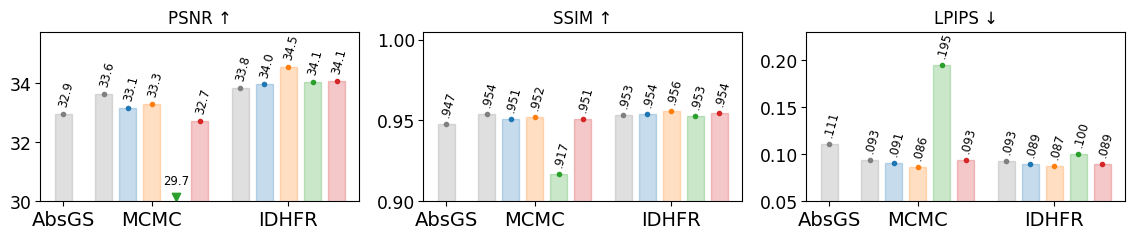

Saved: graphs/da3_edgs_monodepth/legend_da3.svg
EDGS mean init time (all datasets): 102.55s
Monodepth mean init time (all datasets): 98.68s
DA3 mean init time (all datasets): 45.16s


<Figure size 600x100 with 0 Axes>

In [ ]:
# Real init methods with DA3 results
import pandas as pd
from eval_scripts.results_processing.base import (
    TABLE_METRICS,
    drop_scenes_not_present_in_all,
    load_init_method_runs,
)
from eval_scripts.results_processing.plots import (
    grouped_per_metric_barplots_for_each_config,
)
import matplotlib.pyplot as plt


monodepth_init_runs = load_init_method_runs(experiment_name="monodepth_init")
edgs_init_runs = load_init_method_runs(experiment_name="edgs_init")
da3_init_runs = load_init_method_runs(experiment_name="da3_init")

EDGS_LABEL = "$\\text{EDGS}^*$"
MONODEPTH_LABEL = "Monocular Depth"
DA3_LABEL = "DA3"
GT_LABEL = "Laser Init. of same size"
CELL_GRAPH_SUBDIR = "da3_edgs_monodepth"

datasets = sorted(ALL_DATASETS_WITHOUT_ETH3D, reverse=True)


edgs_init_sum = 0
edgs_init_count = 0
monodepth_init_sum = 0
monodepth_init_count = 0
for i, dataset in enumerate(datasets):
    is_last = i == len(datasets) - 1
    print("Dataset:", dataset)
    runs = runs_per_dataset[dataset]

    common_args = {
        "is_default_strategy_config": True,
        "gaussian_cap_fraction": "1.0",
        "init.position_noise_std": "0.0",
    }

    sfm = runs.get_per_scene_metrics_for_params(
        {
            **common_args,
            "init_group": "sfm_baseline",
            "strategy": "DefaultWithGaussianCapStrategy",
        },
    )
    sfm_mcmc = runs.get_per_scene_metrics_for_params(
        {
            **common_args,
            "init_group": "sfm_baseline",
            "strategy": "MCMCStrategy",
        },
    )
    sfm_idhfr = runs.get_per_scene_metrics_for_params(
        {
            **common_args,
            "init_group": "sfm_baseline",
            "strategy": "IDHFRStrategy",
        },
    )

    data = {}
    for strategy in [
        "MCMCStrategy",
        "IDHFRStrategy",
    ]:
        edgs_params = {
            **common_args,
            "strategy": strategy,
            "init_method": "edgs",
            "splat_init.increase_scale_with_fewer_splats": True,
        }
        monodepth_params = {
            **common_args,
            "strategy": strategy,
            "init_method": "monodepth",
        }
        da3_params = {
            **common_args,
            "strategy": strategy,
            "init_method": "da3",
        }
        edgs_runs = runs.get_runs_with_params(edgs_params)
        monodepth_runs = runs.get_runs_with_params(monodepth_params)
        da3_runs = runs.get_runs_with_params(da3_params)

        edgs = edgs_runs.get_per_scene_metrics_for_params({})
        monodepth = monodepth_runs.get_per_scene_metrics_for_params({})
        da3 = da3_runs.get_per_scene_metrics_for_params({})

        strat_name = STRATEGY_NAMES[strategy]
        data.setdefault(strat_name, {})[EDGS_LABEL] = edgs
        data.setdefault(strat_name, {})[MONODEPTH_LABEL] = monodepth
        data.setdefault(strat_name, {})[DA3_LABEL] = da3

        if dataset in GT_DATASETS:
            data.setdefault(strat_name, {})[GT_LABEL] = (
                runs.get_per_scene_metrics_for_params(
                    {
                        **common_args,
                        "strategy": strategy,
                        "init_method": "laser_scan",
                        "init_size_matches_real_init": True,
                        "dense_init.target_points_fraction": "1.0",
                    }
                )
            )

    all_dfs = [x for strat_dict in data.values() for x in strat_dict.values()]
    drop_scenes_not_present_in_all(sfm, sfm_mcmc, *all_dfs)

    data_means = {}
    data_means["AbsGS"] = {"SfM (Size differs)": sfm.mean()}
    data_means["MCMC"] = {"SfM (Size differs)": sfm_mcmc.mean()}
    data_means["IDHFR"] = {"SfM (Size differs)": sfm_idhfr.mean()}

    for strat, method_dict in data.items():
        for method, df in method_dict.items():
            data_means.setdefault(strat, {})[method] = df.mean()

    plot_ranges_per_metric = {
        "eval-all-test/psnr": 5.75,
        "eval-all-test/ssim": 0.105,
        "eval-all-test/lpips": 0.18,
    }
    plot_starts_per_metric_per_dataset = {
        "scannet++": {
            "eval-all-test/psnr": 20,
            "eval-all-test/ssim": 0.825,
            "eval-all-test/lpips": 0.2,
        },
        "eval_on_train_set_scannet++": {
            "eval-all-test/psnr": 30.0,
            "eval-all-test/ssim": 0.9,
            "eval-all-test/lpips": 0.05,
        },
        "mipnerf360": {
            "eval-all-test/psnr": 25.0,
            "eval-all-test/ssim": 0.77,
            "eval-all-test/lpips": 0.1,
        },
        "tanksandtemples": {
            "eval-all-test/psnr": 20.75,
            "eval-all-test/ssim": 0.77,
            "eval-all-test/lpips": 0.12,
        },
    }

    plot_limits_per_metric = {
        metric: (
            plot_starts_per_metric_per_dataset.get(dataset, {}).get(metric, 0),
            plot_starts_per_metric_per_dataset.get(dataset, {}).get(metric, 0)
            + range_val,
        )
        for metric, range_val in plot_ranges_per_metric.items()
    }

    init_method_cmap = plt.cm.tab10

    fig, axes, (handles, labels) = grouped_per_metric_barplots_for_each_config(
        data_means,
        metrics_to_plot=[
            m
            for m in TABLE_METRICS
            if m not in {"train/num-gaussians", "train/total-train-time"}
        ],
        figsize=(14, 2.2),
        label_all_bars=True,
        plot_limits_per_metric=plot_limits_per_metric,
        columns=3,
        rotate_labels_angle=45,
        rotate_all_labels=False,
        rotate_bar_labels_angle=75,
        bar_labels_font_scale=1.2,
        padding_factor=0.55 if "scannet++" in dataset else 0.75,
        legend_y_offset=0.2,
        colors=["gray"] + list(init_method_cmap.colors),
        show_legend=False,
        font_scale=2,
    )

    plt.tight_layout()
    save_figure_svg(fig, CELL_GRAPH_SUBDIR, f"{dataset}_da3")
    plt.show()

    if is_last:
        # Save legend
        fig = plt.figure(figsize=(6, 1))

        legend = fig.legend(
            handles,
            labels,
            loc="center",
            ncol=len(handles),
            columnspacing=0.25,
            handletextpad=0.15,
            frameon=False,
        )

        # Draw the figure so legend gets a size
        fig.canvas.draw()

        # Save ONLY the legend
        bbox = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
        save_figure_svg(fig, CELL_GRAPH_SUBDIR, "legend_da3", bbox_inches=bbox)

edgs_mean_init_time = edgs_init_runs.df["init_only_runtime"].mean()
monodepth_mean_init_time = monodepth_init_runs.df["init_only_runtime"].mean()
da3_mean_init_time = da3_init_runs.df["init_only_runtime"].mean()

print(f"EDGS mean init time (all datasets): {edgs_mean_init_time:.2f}s")
print(f"Monodepth mean init time (all datasets): {monodepth_mean_init_time:.2f}s")
print(f"DA3 mean init time (all datasets): {da3_mean_init_time:.2f}s")

Dataset: scannet++
Common scenes (15): scannet++/6115eddb86, scannet++/9071e139d9, scannet++/3db0a1c8f3, scannet++/f3d64c30f8, scannet++/e7af285f7d, scannet++/c5439f4607, scannet++/825d228aec, scannet++/bcd2436daf, scannet++/b0a08200c9, scannet++/5eb31827b7, scannet++/3f15a9266d, scannet++/40aec5fffa, scannet++/5748ce6f01, scannet++/bde1e479ad, scannet++/7831862f02
Saved: graphs/gt_init_diff_strategies_and_sizes/scannetpp_line_metrics.svg


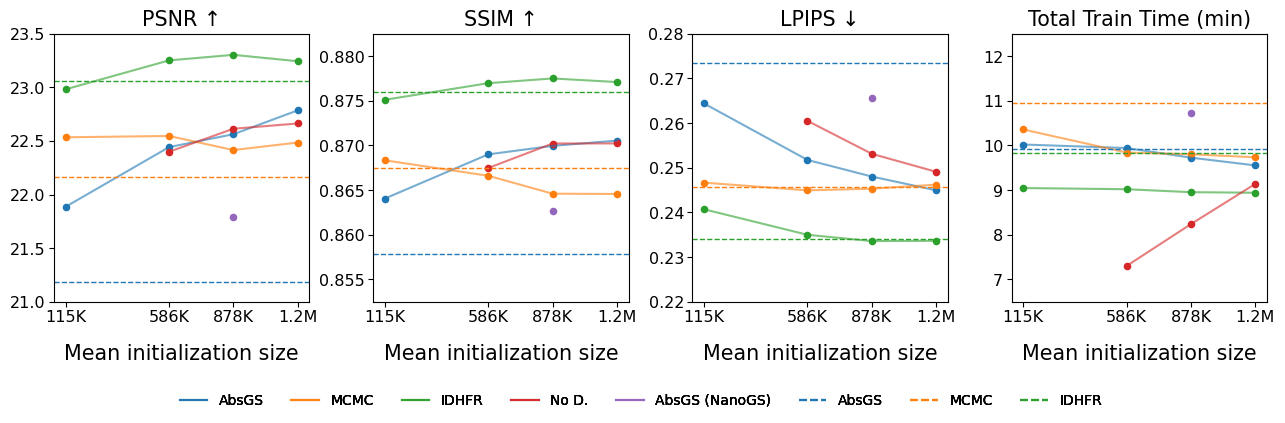

Saved: graphs/gt_init_diff_strategies_and_sizes/main_graph_legend.svg


<Figure size 1565.22x52.1739 with 0 Axes>

Dataset: eval_on_train_set_scannet++
Common scenes (15): eval_on_train_set_scannet++/f3d64c30f8, eval_on_train_set_scannet++/3db0a1c8f3, eval_on_train_set_scannet++/bde1e479ad, eval_on_train_set_scannet++/bcd2436daf, eval_on_train_set_scannet++/5eb31827b7, eval_on_train_set_scannet++/40aec5fffa, eval_on_train_set_scannet++/7831862f02, eval_on_train_set_scannet++/b0a08200c9, eval_on_train_set_scannet++/825d228aec, eval_on_train_set_scannet++/6115eddb86, eval_on_train_set_scannet++/c5439f4607, eval_on_train_set_scannet++/5748ce6f01, eval_on_train_set_scannet++/9071e139d9, eval_on_train_set_scannet++/e7af285f7d, eval_on_train_set_scannet++/3f15a9266d
Saved: graphs/gt_init_diff_strategies_and_sizes/eval_on_train_set_scannetpp_line_metrics.svg


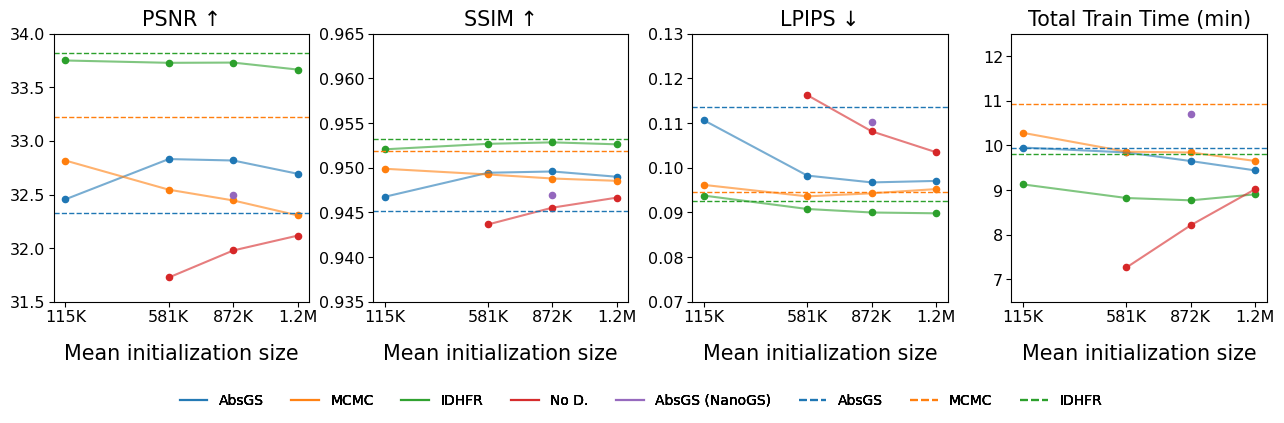

Saved: graphs/gt_init_diff_strategies_and_sizes/main_graph_legend.svg


<Figure size 1565.22x52.1739 with 0 Axes>

Dataset: eth3d
Common scenes (7): eth3d/terrains, eth3d/terrace, eth3d/office, eth3d/relief_2, eth3d/kicker, eth3d/pipes, eth3d/relief
Saved: graphs/gt_init_diff_strategies_and_sizes/eth3d_line_metrics.svg


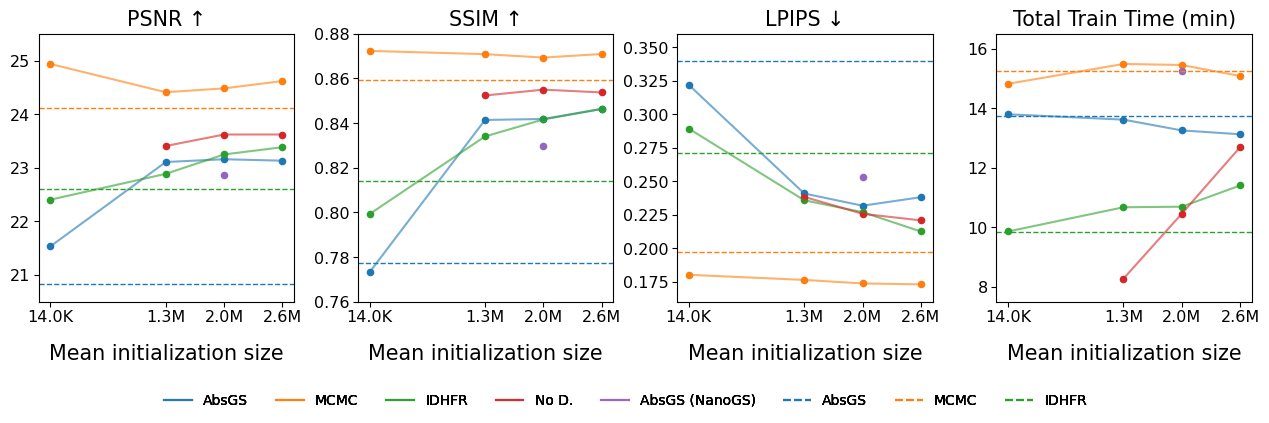

Saved: graphs/gt_init_diff_strategies_and_sizes/main_graph_legend.svg


<Figure size 1565.22x52.1739 with 0 Axes>

In [12]:
# Laser Scan with NanoGS results
from matplotlib import pyplot as plt
from eval_scripts.results_processing.base import (
    TABLE_METRICS,
    drop_scenes_not_present_in_all,
)
from eval_scripts.results_processing.plots import (
    grouped_per_metric_line_charts_for_each_config,
)


common_args = {
    "is_default_strategy_config": True,
    "init.position_noise_std": "0.0",
    "gaussian_cap_fraction": "1.0",
}
CELL_GRAPH_SUBDIR = "gt_init_diff_strategies_and_sizes"

for dataset in GT_DATASETS:
    print("Dataset:", dataset)
    runs = runs_per_dataset[dataset]

    data = {}

    sfm = runs.get_per_scene_metrics_for_params(
        {
            "init_group": "sfm_baseline",
            "strategy": "DefaultWithGaussianCapStrategy",
        }
    )

    sfm_mcmc = runs.get_per_scene_metrics_for_params(
        {
            "init_group": "sfm_baseline",
            "strategy": "MCMCStrategy",
        }
    )

    sfm_idhfr = runs.get_per_scene_metrics_for_params(
        {
            "init_group": "sfm_baseline",
            "strategy": "IDHFRStrategy",
        }
    )

    for strategy in ["DefaultWithGaussianCapStrategy", "MCMCStrategy", "IDHFRStrategy"]:
        args = {
            **common_args,
            "strategy": strategy,
            "init_method": "laser_scan",
            "init_size_matches_sfm": True,
        }
        x = runs.get_per_scene_metrics_for_params(
            args,
            metrics=TABLE_METRICS
            + ["dense_init.target_num_points", "dense_init.target_points_fraction"],
        )
        strat_name = STRATEGY_NAMES[strategy]
        data.setdefault(strat_name, {})["as_sfm"] = x

    for strategy in [
        "DefaultWithGaussianCapStrategy",
        "MCMCStrategy",
        "DefaultWithoutADCStrategy",
        "IDHFRStrategy",
    ]:
        for size_fraction in ["0.5", "0.75", "1.0"]:
            args = {
                **common_args,
                "strategy": strategy,
                "dense_init.target_points_fraction": size_fraction,
                "init_method": "laser_scan",
                "init_size_matches_gmax": True,
            }
            runs = runs.copy()
            x = runs.get_per_scene_metrics_for_params(
                args,
                metrics=TABLE_METRICS
                + ["dense_init.target_num_points", "dense_init.target_points_fraction"],
            )
            strat_name = STRATEGY_NAMES[strategy]
            data.setdefault(strat_name, {})[size_fraction] = x

    for strategy in [
        "DefaultWithGaussianCapStrategy",
        # "MCMCStrategy",
    ]:
        size_fraction = "0.75"
        args = {
            **common_args,
            "strategy": strategy,
            "dense_init.target_points_fraction": size_fraction,
            "init_method": "laser_scan",
            "init_size_matches_gmax": True,
            "nanogs_simplify_iter": "500"
        }
        args["is_default_strategy_config"] = False
        x = runs.get_per_scene_metrics_for_params(
            args,
            metrics=TABLE_METRICS
            + ["dense_init.target_num_points", "dense_init.target_points_fraction"],
        )
        data.setdefault(f"{STRATEGY_NAMES[strategy]} (NanoGS)", {})[size_fraction] = x

    all_dfs = [sfm, sfm_mcmc] + [x for g in data.values() for x in g.values()]
    drop_scenes_not_present_in_all(*all_dfs)

    data_with_num_points = {}
    for strategy, df_per_fraction in data.items():
        data_with_num_points[strategy] = {}
        for fraction, df in df_per_fraction.items():
            df["dense_init.target_num_points"] = df[
                "dense_init.target_num_points"
            ].astype(float)
            # All should have same fraction
            assert (
                df["dense_init.target_points_fraction"]
                == df["dense_init.target_points_fraction"].iloc[0]
            ).all()
            df["dense_init.target_points_fraction"] = df[
                "dense_init.target_points_fraction"
            ].astype(float)
            num_points = (
                df["dense_init.target_num_points"]
                * df["dense_init.target_points_fraction"].iloc[0]
            )
            data_with_num_points[strategy][num_points.mean()] = df
    data_with_num_points = {
        a: {b: df.mean() for b, df in dfs.items()}
        for a, dfs in data_with_num_points.items()
    }

    plot_ranges_per_metric_per_dataset = {
        "default": {
            "eval-all-test/psnr": 2.5,
            "eval-all-test/ssim": 0.03,
            "eval-all-test/lpips": 0.06,
            "train/total-train-time": 6,
        },
        "eth3d": {
            "eval-all-test/psnr": 5,
            "eval-all-test/ssim": 0.12,
            "eval-all-test/lpips": 0.2,
            "train/total-train-time": 9,
        },
    }
    plot_starts_per_metric_per_dataset = {
        "scannet++": {
            "eval-all-test/psnr": 21,
            "eval-all-test/ssim": 0.8525,
            "eval-all-test/lpips": 0.22,
            "train/total-train-time": 6.5,
        },
        "eval_on_train_set_scannet++": {
            "eval-all-test/psnr": 31.5,
            "eval-all-test/ssim": 0.935,
            "eval-all-test/lpips": 0.07,
            "train/total-train-time": 6.5,
        },
        "eth3d": {
            "eval-all-test/psnr": 20.5,
            "eval-all-test/ssim": 0.76,
            "eval-all-test/lpips": 0.16,
            "train/total-train-time": 7.5,
        },
    }
    plot_limits_per_metric = {
        metric: (
            plot_starts_per_metric_per_dataset.get(dataset, {}).get(metric, 0),
            plot_starts_per_metric_per_dataset.get(dataset, {}).get(metric, 0)
            + range_val,
        )
        for metric, range_val in plot_ranges_per_metric_per_dataset.get(
            dataset, plot_ranges_per_metric_per_dataset["default"]
        ).items()
    }

    fig_downscale = 1.15
    fig, axes = grouped_per_metric_line_charts_for_each_config(
        data_with_num_points,
        extra_data_lines={
            "AbsGS": sfm.mean(),
            "MCMC": sfm_mcmc.mean(),
            "IDHFR": sfm_idhfr.mean(),
        },
        metrics_to_plot=[
            "eval-all-test/psnr",
            "eval-all-test/ssim",
            "eval-all-test/lpips",
            "train/total-train-time",
        ],
        columns=4,
        plot_limits_per_metric=plot_limits_per_metric,
        xlabel="Mean initialization size",
        figsize=(18 / fig_downscale, 4 / fig_downscale),
        legend_y_offset=0.1,
        remove_y_axis_labels=True,
        show_legend=True,
        fontsize_scale=1.65,
    )

    save_figure_svg(fig, CELL_GRAPH_SUBDIR, f"{dataset}_line_metrics")
    plt.show()

    # Create separate legend figure
    fig_legend = plt.figure(figsize=(18 / fig_downscale, 0.6 / fig_downscale))
    legend_handles, legend_labels = axes[0].get_legend_handles_labels()
    fig_legend.legend(
        legend_handles,
        legend_labels,
        loc="center",
        ncol=len(legend_labels),
        frameon=False,
    )
    save_figure_svg(fig_legend, CELL_GRAPH_SUBDIR, "main_graph_legend")
    plt.show()

    # Remove legend from main figure
    for ax in axes:
        legend = ax.get_legend()
        if legend:
            legend.remove()

Dataset: eval_on_train_set_scannet++
Num nanogs runs: 1
Common scenes (15): eval_on_train_set_scannet++/6115eddb86, eval_on_train_set_scannet++/5748ce6f01, eval_on_train_set_scannet++/825d228aec, eval_on_train_set_scannet++/3db0a1c8f3, eval_on_train_set_scannet++/b0a08200c9, eval_on_train_set_scannet++/3f15a9266d, eval_on_train_set_scannet++/9071e139d9, eval_on_train_set_scannet++/bde1e479ad, eval_on_train_set_scannet++/5eb31827b7, eval_on_train_set_scannet++/e7af285f7d, eval_on_train_set_scannet++/c5439f4607, eval_on_train_set_scannet++/40aec5fffa, eval_on_train_set_scannet++/7831862f02, eval_on_train_set_scannet++/bcd2436daf, eval_on_train_set_scannet++/f3d64c30f8


/tmp/ipykernel_44491/3721729721.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: graphs/edgs_monodepth_vs_gt/eval_on_train_set_scannetpp_main.svg


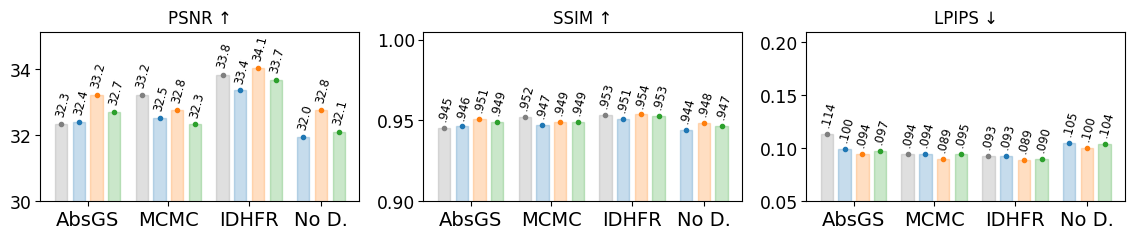

Dataset: tanksandtemples
Num nanogs runs: 80
Common scenes (14): tanksandtemples/church, tanksandtemples/auditorium, tanksandtemples/truck, tanksandtemples/family, tanksandtemples/palace, tanksandtemples/caterpillar, tanksandtemples/train, tanksandtemples/temple, tanksandtemples/m60, tanksandtemples/ballroom, tanksandtemples/lighthouse, tanksandtemples/horse, tanksandtemples/barn, tanksandtemples/meetingroom


/tmp/ipykernel_44491/3721729721.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: graphs/edgs_monodepth_vs_gt/tanksandtemples_main.svg


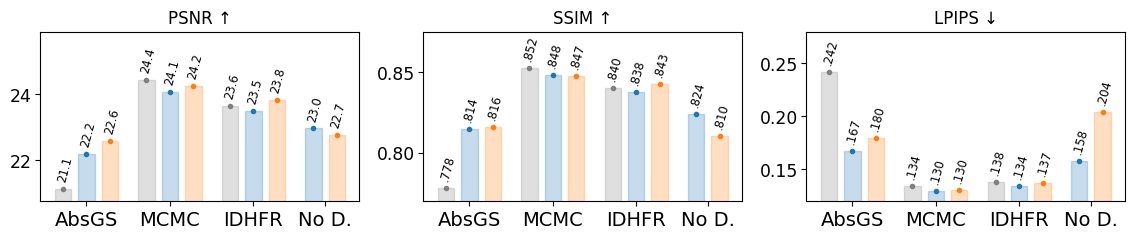

Dataset: scannet++
Num nanogs runs: 0
Common scenes (15): scannet++/40aec5fffa, scannet++/6115eddb86, scannet++/f3d64c30f8, scannet++/3db0a1c8f3, scannet++/e7af285f7d, scannet++/7831862f02, scannet++/bcd2436daf, scannet++/5748ce6f01, scannet++/3f15a9266d, scannet++/bde1e479ad, scannet++/b0a08200c9, scannet++/5eb31827b7, scannet++/9071e139d9, scannet++/825d228aec, scannet++/c5439f4607


/tmp/ipykernel_44491/3721729721.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: graphs/edgs_monodepth_vs_gt/scannetpp_main.svg


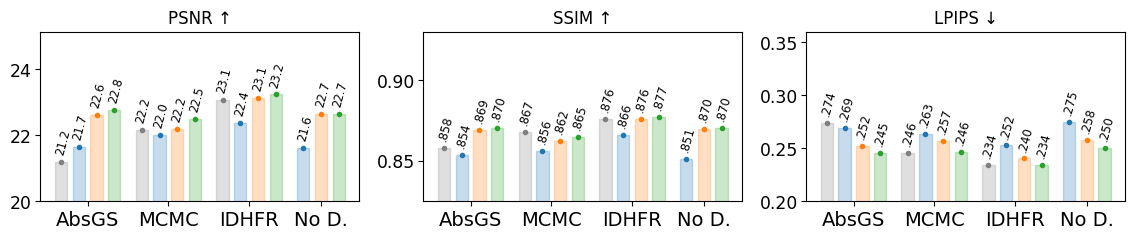

Dataset: mipnerf360
Num nanogs runs: 53
Common scenes (9): mipnerf360/kitchen, mipnerf360/room, mipnerf360/bonsai, mipnerf360/flowers, mipnerf360/bicycle, mipnerf360/stump, mipnerf360/counter, mipnerf360/garden, mipnerf360/treehill


/tmp/ipykernel_44491/3721729721.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: graphs/edgs_monodepth_vs_gt/mipnerf360_main.svg


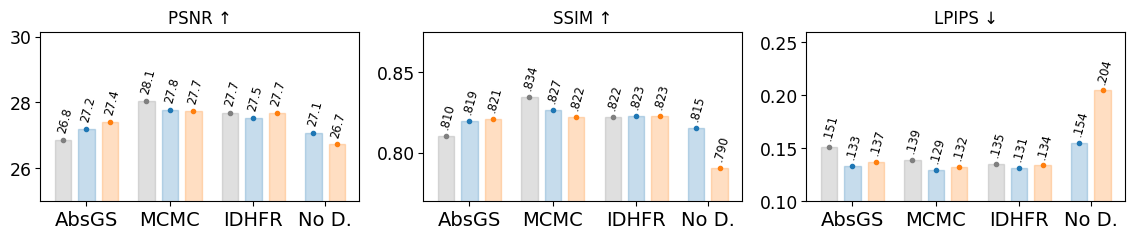

Saved: graphs/edgs_monodepth_vs_gt/legend_main.svg
EDGS mean init time (all datasets): 102.55s
Monodepth mean init time (all datasets): 98.68s


<Figure size 600x100 with 0 Axes>

In [32]:
# Real Init NanoGS improvement
import pandas as pd
from eval_scripts.results_processing.base import (
    TABLE_METRICS,
    drop_scenes_not_present_in_all,
    load_init_method_runs,
)
from eval_scripts.results_processing.plots import (
    grouped_per_metric_barplots_for_each_config,
)
import matplotlib.pyplot as plt

monodepth_init_runs = load_init_method_runs(experiment_name="monodepth_init")
edgs_init_runs = load_init_method_runs(experiment_name="edgs_init")

EDGS_LABEL = "$EDGS^*$"
MONODEPTH_LABEL = "Monocular Depth"
GT_LABEL = "Laser Init. of same size"
CELL_GRAPH_SUBDIR = "edgs_monodepth_vs_gt"

datasets = ALL_DATASETS_WITHOUT_ETH3D

edgs_init_sum = 0
edgs_init_count = 0
monodepth_init_sum = 0
monodepth_init_count = 0
for i, dataset in enumerate(datasets):
    is_last = i == len(datasets) - 1
    print("Dataset:", dataset)
    runs = runs_per_dataset[dataset]

    nanogs_runs = runs.get_runs_with_params(
        {
            "nanogs_simplify_iter": "500", })
    print(f"Num nanogs runs: {len(nanogs_runs.df)}")

    common_args = {
        "is_default_strategy_config": True,
        "gaussian_cap_fraction": "1.0",
        "init.position_noise_std": "0.0",
    }

    sfm = runs.get_per_scene_metrics_for_params(
        {
            **common_args,
            "init_group": "sfm_baseline",
            "strategy": "DefaultWithGaussianCapStrategy",
        },
    )
    sfm_mcmc = runs.get_per_scene_metrics_for_params(
        {
            **common_args,
            "init_group": "sfm_baseline",
            "strategy": "MCMCStrategy",
        },
    )
    sfm_idhfr = runs.get_per_scene_metrics_for_params(
        {
            **common_args,
            "init_group": "sfm_baseline",
            "strategy": "IDHFRStrategy",
        },
    )

    data = {}
    for strategy in [
        "DefaultWithoutADCStrategy",
        "DefaultWithGaussianCapStrategy",
        "MCMCStrategy",
        "IDHFRStrategy",
    ]:
        edgs_params = {
            **common_args,
            "strategy": strategy,
            "init_method": "edgs",
            "splat_init.increase_scale_with_fewer_splats": True,
        }
        monodepth_params = {
            **common_args,
            "strategy": strategy,
            "init_method": "monodepth",
        }
        edgs_runs = runs.get_runs_with_params(edgs_params)
        monodepth_runs = runs.get_runs_with_params(monodepth_params)

        edgs = edgs_runs.get_per_scene_metrics_for_params({})
        monodepth = monodepth_runs.get_per_scene_metrics_for_params({})

        strat_name = STRATEGY_NAMES[strategy]
        data.setdefault(strat_name, {})[EDGS_LABEL] = edgs
        data.setdefault(strat_name, {})[MONODEPTH_LABEL] = monodepth

        if dataset in GT_DATASETS:
            data.setdefault(strat_name, {})[GT_LABEL] = (
                runs.get_per_scene_metrics_for_params(
                    {
                        **common_args,
                        "strategy": strategy,
                        "init_method": "laser_scan",
                        "init_size_matches_real_init": True,
                        "dense_init.target_points_fraction": "1.0",
                    }
                )
            )

    all_dfs = [x for strat_dict in data.values() for x in strat_dict.values()]
    drop_scenes_not_present_in_all(sfm, sfm_mcmc, *all_dfs)

    data_means = {}
    data_means["AbsGS"] = {"SfM (Size differs)": sfm.mean()}
    data_means["MCMC"] = {"SfM (Size differs)": sfm_mcmc.mean()}
    data_means["IDHFR"] = {"SfM (Size differs)": sfm_idhfr.mean()}

    for strat, method_dict in data.items():
        for method, df in method_dict.items():
            data_means.setdefault(strat, {})[method] = df.mean()

    plot_ranges_per_metric = {
        "eval-all-test/psnr": 5.15,
        "eval-all-test/ssim": 0.105,
        "eval-all-test/lpips": 0.16,
    }
    plot_starts_per_metric_per_dataset = {
        "scannet++": {
            "eval-all-test/psnr": 20,
            "eval-all-test/ssim": 0.825,
            "eval-all-test/lpips": 0.2,
        },
        "eval_on_train_set_scannet++": {
            "eval-all-test/psnr": 30.0,
            "eval-all-test/ssim": 0.9,
            "eval-all-test/lpips": 0.05,
        },
        "mipnerf360": {
            "eval-all-test/psnr": 25.0,
            "eval-all-test/ssim": 0.77,
            "eval-all-test/lpips": 0.1,
        },
        "tanksandtemples": {
            "eval-all-test/psnr": 20.75,
            "eval-all-test/ssim": 0.77,
            "eval-all-test/lpips": 0.12,
        },
    }

    plot_limits_per_metric = {
        metric: (
            plot_starts_per_metric_per_dataset.get(dataset, {}).get(metric, 0),
            plot_starts_per_metric_per_dataset.get(dataset, {}).get(metric, 0)
            + range_val,
        )
        for metric, range_val in plot_ranges_per_metric.items()
    }

    init_method_cmap = plt.cm.tab10

    fig, axes, (handles, labels) = grouped_per_metric_barplots_for_each_config(
        data_means,
        metrics_to_plot=[
            m
            for m in TABLE_METRICS
            if m not in {"train/num-gaussians", "train/total-train-time"}
        ],
        figsize=(14, 2.2),
        label_all_bars=True,
        plot_limits_per_metric=plot_limits_per_metric,
        columns=3,
        rotate_labels_angle=45,
        rotate_all_labels=False,
        rotate_bar_labels_angle=75,
        bar_labels_font_scale=1.2,
        padding_factor=0.55 if "scannet++" in dataset else 0.75,
        legend_y_offset=0.2,
        colors=["gray"] + list(init_method_cmap.colors),
        show_legend=False,
        font_scale=2,
    )

    plt.tight_layout()
    save_figure_svg(fig, CELL_GRAPH_SUBDIR, f"{dataset}_main")
    plt.show()

    if is_last:
        # Save legend
        fig = plt.figure(figsize=(6, 1))

        legend = fig.legend(
            handles,
            labels,
            loc="center",
            ncol=len(handles),
            columnspacing=0.25,
            handletextpad=0.15,
            frameon=False,
        )

        # Draw the figure so legend gets a size
        fig.canvas.draw()

        # Save ONLY the legend
        bbox = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
        save_figure_svg(fig, CELL_GRAPH_SUBDIR, "legend_main", bbox_inches=bbox)

edgs_mean_init_time = edgs_init_runs.df["init_only_runtime"].mean()
monodepth_mean_init_time = monodepth_init_runs.df["init_only_runtime"].mean()

print(f"EDGS mean init time (all datasets): {edgs_mean_init_time:.2f}s")
print(f"Monodepth mean init time (all datasets): {monodepth_mean_init_time:.2f}s")